In [1]:
from pathlib import Path

try:
    from helpers.preprocess import preprocess_model
except ImportError:
    from preprocess import preprocess_model

MODEL_FILES = [
    "inputs/validation/validation_3d_truss.json",
    "inputs/validation/validation_3d_frame.json",
    "inputs/validation/verification_special_effects.json",
]

for model_path in MODEL_FILES:
    print("\n" + "=" * 70)
    print(f"Testing model file  {model_path}")
    
    raw_model, clean_model, data, summary = preprocess_model(model_path)
    
    print("Summary")
    for key, value in summary.items():
        print(f"  {key} = {value}")
    
    print("Restrained DOFs")
    print(data["restrained_dofs"])
    
    print("Free DOFs")
    print(data["free_dofs"])
    
    print("Prescribed displacements")
    print(data["prescribed_displacements"])
    
    print("Nodal load vector")
    print(data["nodal_load_vector"])


Testing model file  inputs/validation/validation_3d_truss.json
Summary
  model_name = validation_3d_truss
  n_nodes = 2
  n_elements = 1
  n_truss_elements = 1
  n_frame_elements = 0
  ndof_total = 12
  n_free_dofs = 1
  n_restrained_dofs = 11
  n_support_nodes = 2
  n_nodal_loads = 1
  n_member_loads = 0
  n_prescribed_displacements = 0
  n_temperature_loads = 0
  n_fabrication_errors = 0
Restrained DOFs
[0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11]
Free DOFs
[6]
Prescribed displacements
{}
Nodal load vector
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]

Testing model file  inputs/validation/validation_3d_frame.json
Summary
  model_name = validation_3d_frame
  n_nodes = 2
  n_elements = 1
  n_truss_elements = 0
  n_frame_elements = 1
  ndof_total = 12
  n_free_dofs = 6
  n_restrained_dofs = 6
  n_support_nodes = 1
  n_nodal_loads = 1
  n_member_loads = 0
  n_prescribed_displacements = 0
  n_temperature_loads = 0
  n_fabrication_errors = 0
Restrained DOFs
[0, 1, 2, 3, 4, 5]
Free DOFs
[6, 7, 8, 9, 10, 1

In [2]:
try:
    from helpers.elements_3d import get_element_basic_3d_data
except ImportError:
    from elements_3d import get_element_basic_3d_data

TEST_MODELS = [
    "inputs/validation/validation_3d_truss.json",
    "inputs/validation/validation_3d_frame.json",
]

for model_path in TEST_MODELS:
    print("\n" + "=" * 70)
    print(f"Geometry and transformation test for  {model_path}")

    _, clean_model, data, summary = preprocess_model(model_path)

    for elem_id in data["element_ids"]:
        elem_data = get_element_basic_3d_data(clean_model, elem_id)
        print(f"\nElement {elem_id}")
        print("Length")
        print(elem_data["L"])
        print("DOF map")
        print(elem_data["dof_map"])
        print("Rotation matrix R")
        print(elem_data["R"])
        print("Transformation matrix shape")
        print(elem_data["T"].shape)


Geometry and transformation test for  inputs/validation/validation_3d_truss.json

Element 1
Length
10.0
DOF map
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Rotation matrix R
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Transformation matrix shape
(12, 12)

Geometry and transformation test for  inputs/validation/validation_3d_frame.json

Element 1
Length
10.0
DOF map
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Rotation matrix R
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Transformation matrix shape
(12, 12)


In [3]:
from pathlib import Path

p = Path("helpers/elements_3d.py")
print("file exists =", p.exists())

text = p.read_text(encoding="utf-8")
print("function found =", "get_truss_element_stiffness_data" in text)

file exists = True
function found = True


In [4]:
import importlib
import helpers.elements_3d as e3d

importlib.reload(e3d)

from helpers.elements_3d import get_truss_element_stiffness_data
print("reload successful")

reload successful


In [5]:
import numpy as np

try:
    from helpers.elements_3d import get_truss_element_stiffness_data
except ImportError:
    from elements_3d import get_truss_element_stiffness_data

_, clean_model, data, summary = preprocess_model("inputs/validation/validation_3d_truss.json")

elem_id = data["element_ids"][0]
truss_data = get_truss_element_stiffness_data(clean_model, elem_id)

np.set_printoptions(suppress=True, linewidth=140)

print("Element id")
print(elem_id)

print("\nLocal truss stiffness matrix")
print(truss_data["k_local"])

print("\nGlobal truss stiffness matrix")
print(truss_data["k_global"])

print("\nSymmetry check for global stiffness")
print(np.allclose(truss_data["k_global"], truss_data["k_global"].T))

Element id
1

Local truss stiffness matrix
[[ 2900.     0.     0.     0.     0.     0. -2900.     0.     0.     0.     0.     0.]
 [    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.]
 [    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.]
 [    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.]
 [    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.]
 [    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.]
 [-2900.     0.     0.     0.     0.     0.  2900.     0.     0.     0.     0.     0.]
 [    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.]
 [    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.]
 [    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.]
 [    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.]


In [6]:
import importlib
import numpy as np
import helpers.elements_3d as e3d

importlib.reload(e3d)

from helpers.elements_3d import get_frame_element_stiffness_data

_, clean_model, data, summary = preprocess_model("inputs/validation/validation_3d_frame.json")

elem_id = data["element_ids"][0]
frame_data = get_frame_element_stiffness_data(clean_model, elem_id)

np.set_printoptions(suppress=True, linewidth=160)

print("Element id")
print(elem_id)

print("\nLocal frame stiffness matrix")
print(frame_data["k_local"])

print("\nGlobal frame stiffness matrix")
print(frame_data["k_global"])

print("\nSymmetry check for local stiffness")
print(np.allclose(frame_data["k_local"], frame_data["k_local"].T))

print("\nSymmetry check for global stiffness")
print(np.allclose(frame_data["k_global"], frame_data["k_global"].T))

Element id
1

Local frame stiffness matrix
[[ 2900.     0.     0.     0.     0.     0. -2900.     0.     0.     0.     0.     0.]
 [    0.   348.     0.     0.     0.  1740.     0.  -348.     0.     0.     0.  1740.]
 [    0.     0.   348.     0. -1740.     0.     0.     0.  -348.     0. -1740.     0.]
 [    0.     0.     0.  1120.     0.     0.     0.     0.     0. -1120.     0.     0.]
 [    0.     0. -1740.     0. 11600.     0.     0.     0.  1740.     0.  5800.     0.]
 [    0.  1740.     0.     0.     0. 11600.     0. -1740.     0.     0.     0.  5800.]
 [-2900.     0.     0.     0.     0.     0.  2900.     0.     0.     0.     0.     0.]
 [    0.  -348.     0.     0.     0. -1740.     0.   348.     0.     0.     0. -1740.]
 [    0.     0.  -348.     0.  1740.     0.     0.     0.   348.     0.  1740.     0.]
 [    0.     0.     0. -1120.     0.     0.     0.     0.     0.  1120.     0.     0.]
 [    0.     0. -1740.     0.  5800.     0.     0.     0.  1740.     0. 11600.     0.]


In [7]:
import importlib
import numpy as np
import helpers.assembly as asm

importlib.reload(asm)

from helpers.assembly import assemble_global_stiffness, partition_matrix

TEST_MODELS = [
    "inputs/validation/validation_3d_truss.json",
    "inputs/validation/validation_3d_frame.json",
]

np.set_printoptions(suppress=True, linewidth=160)

for model_path in TEST_MODELS:
    print("\n" + "=" * 70)
    print(f"Assembly test for  {model_path}")

    _, clean_model, data, summary = preprocess_model(model_path)

    K_global, element_data_list = assemble_global_stiffness(clean_model, data)

    print("Global stiffness matrix shape")
    print(K_global.shape)

    print("Global stiffness symmetry check")
    print(np.allclose(K_global, K_global.T))

    K_ff, K_fr, K_rf, K_rr = partition_matrix(
        K_global,
        data["free_dofs"],
        data["restrained_dofs"],
    )

    print("K_ff shape")
    print(K_ff.shape)

    print("K_fr shape")
    print(K_fr.shape)

    print("K_rf shape")
    print(K_rf.shape)

    print("K_rr shape")
    print(K_rr.shape)

    print("K_ff")
    print(K_ff)


Assembly test for  inputs/validation/validation_3d_truss.json
Global stiffness matrix shape
(12, 12)
Global stiffness symmetry check
True
K_ff shape
(1, 1)
K_fr shape
(1, 11)
K_rf shape
(11, 1)
K_rr shape
(11, 11)
K_ff
[[2900.]]

Assembly test for  inputs/validation/validation_3d_frame.json
Global stiffness matrix shape
(12, 12)
Global stiffness symmetry check
True
K_ff shape
(6, 6)
K_fr shape
(6, 6)
K_rf shape
(6, 6)
K_rr shape
(6, 6)
K_ff
[[ 2900.     0.     0.     0.     0.     0.]
 [    0.   348.     0.     0.     0. -1740.]
 [    0.     0.   348.     0.  1740.     0.]
 [    0.     0.     0.  1120.     0.     0.]
 [    0.     0.  1740.     0. 11600.     0.]
 [    0. -1740.     0.     0.     0. 11600.]]


In [8]:
import importlib
import numpy as np
import helpers.solver as sol

importlib.reload(sol)

from helpers.assembly import assemble_global_stiffness
from helpers.solver import solve_linear_system

TEST_MODELS = [
    "inputs/validation/validation_3d_truss.json",
    "inputs/validation/validation_3d_frame.json",
]

np.set_printoptions(suppress=True, linewidth=160)

for model_path in TEST_MODELS:
    print("\n" + "=" * 70)
    print(f"Linear solve test for  {model_path}")

    _, clean_model, data, summary = preprocess_model(model_path)
    K_global, element_data_list = assemble_global_stiffness(clean_model, data)
    results = solve_linear_system(K_global, data)

    print("Full displacement vector U")
    print(results["U"])

    print("\nFree displacement vector Uf")
    print(results["Uf"])

    print("\nRestrained displacement vector Ur")
    print(results["Ur"])

    print("\nReaction residual vector R")
    print(results["R"])

    print("\nReactions at restrained DOFs")
    print(results["reactions_at_restrained_dofs"])


Linear solve test for  inputs/validation/validation_3d_truss.json
Full displacement vector U
[0.         0.         0.         0.         0.         0.         0.00034483 0.         0.         0.         0.         0.        ]

Free displacement vector Uf
[0.00034483]

Restrained displacement vector Ur
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Reaction residual vector R
[-1.  0.  0.  0.  0.  0. -0.  0.  0.  0.  0.  0.]

Reactions at restrained DOFs
[-1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]

Linear solve test for  inputs/validation/validation_3d_frame.json
Full displacement vector U
[ 0.          0.          0.          0.          0.          0.          0.         -0.01149425  0.          0.         -0.         -0.00172414]

Free displacement vector Uf
[ 0.         -0.01149425  0.          0.         -0.         -0.00172414]

Restrained displacement vector Ur
[0. 0. 0. 0. 0. 0.]

Reaction residual vector R
[ 0.  1.  0.  0.  0. 10.  0.  0.  0.  0.  0. -0.]

Reactions at restrained DOFs


In [9]:
import importlib
import numpy as np
import helpers.postprocess as pp

importlib.reload(pp)

from helpers.assembly import assemble_global_stiffness
from helpers.solver import solve_linear_system
from helpers.postprocess import recover_all_element_responses

TEST_MODELS = [
    "inputs/validation/validation_3d_truss.json",
    "inputs/validation/validation_3d_frame.json",
]

np.set_printoptions(suppress=True, linewidth=160)

for model_path in TEST_MODELS:
    print("\n" + "=" * 70)
    print(f"Element recovery test for  {model_path}")

    _, clean_model, data, summary = preprocess_model(model_path)
    K_global, element_data_list = assemble_global_stiffness(clean_model, data)
    results = solve_linear_system(K_global, data)

    responses = recover_all_element_responses(clean_model, data, results["U"])

    for resp in responses:
        print(f"\nElement {resp['elem_id']}")
        print("Global element displacement vector")
        print(resp["u_global_elem"])
        print("\nLocal element displacement vector")
        print(resp["v_local_elem"])
        print("\nLocal element end force vector")
        print(resp["q_local_elem"])
        print("\nGlobal element end force vector")
        print(resp["f_global_elem"])


Element recovery test for  inputs/validation/validation_3d_truss.json

Element 1
Global element displacement vector
[0.         0.         0.         0.         0.         0.         0.00034483 0.         0.         0.         0.         0.        ]

Local element displacement vector
[0.         0.         0.         0.         0.         0.         0.00034483 0.         0.         0.         0.         0.        ]

Local element end force vector
[-1.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.]

Global element end force vector
[-1.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.]

Element recovery test for  inputs/validation/validation_3d_frame.json

Element 1
Global element displacement vector
[ 0.          0.          0.          0.          0.          0.          0.         -0.01149425  0.          0.         -0.         -0.00172414]

Local element displacement vector
[ 0.          0.          0.          0.          0.          0.          0.         -0.01149425  0.          0.     

In [10]:
import importlib
import numpy as np
import helpers.solver as sol

importlib.reload(sol)

from helpers.solver import solve_complete_model

TEST_MODELS = [
    "inputs/validation/validation_3d_truss.json",
    "inputs/validation/validation_3d_frame.json",
]

np.set_printoptions(suppress=True, linewidth=160)

for model_path in TEST_MODELS:
    print("\n" + "=" * 70)
    print(f"Complete model run for  {model_path}")

    _, clean_model, data, summary = preprocess_model(model_path)
    package = solve_complete_model(clean_model, data)

    print("Model name")
    print(summary["model_name"])

    print("\nFull displacement vector")
    print(package["results"]["U"])

    print("\nReactions at restrained DOFs")
    print(package["results"]["reactions_at_restrained_dofs"])

    print("\nNumber of recovered elements")
    print(len(package["element_responses"]))


Complete model run for  inputs/validation/validation_3d_truss.json
Model name
validation_3d_truss

Full displacement vector
[0.         0.         0.         0.         0.         0.         0.00034483 0.         0.         0.         0.         0.        ]

Reactions at restrained DOFs
[-1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]

Number of recovered elements
1

Complete model run for  inputs/validation/validation_3d_frame.json
Model name
validation_3d_frame

Full displacement vector
[ 0.          0.          0.          0.          0.          0.          0.         -0.01149425  0.          0.         -0.         -0.00172414]

Reactions at restrained DOFs
[ 0.  1.  0.  0.  0. 10.]

Number of recovered elements
1


In [11]:
import numpy as np

# Truss validation against hand calculation
model_path = "inputs/validation/validation_3d_truss.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

U = package["results"]["U"]
R = package["results"]["R"]

# Known hand values for this model
# One 10 ft bar, E = 29000 kip/ft^2 style project units here, A = 1.0, P = 1.0
# axial stiffness = EA/L = 2900
# expected free displacement at node 2 ux = P / (EA/L) = 1 / 2900
expected_u_node2_ux = 1.0 / 2900.0
expected_reaction_node1_ux = -1.0

actual_u_node2_ux = U[6]
actual_reaction_node1_ux = R[0]

disp_ok = np.isclose(actual_u_node2_ux, expected_u_node2_ux, atol=1e-12)
react_ok = np.isclose(actual_reaction_node1_ux, expected_reaction_node1_ux, atol=1e-12)

print("Truss validation")
print(f"Expected node 2 ux displacement = {expected_u_node2_ux:.12f}")
print(f"Actual   node 2 ux displacement = {actual_u_node2_ux:.12f}")
print()
print(f"Expected node 1 ux reaction     = {expected_reaction_node1_ux:.12f}")
print(f"Actual   node 1 ux reaction     = {actual_reaction_node1_ux:.12f}")
print()
print(f"Displacement check passed = {disp_ok}")
print(f"Reaction check passed     = {react_ok}")
print(f"Overall validation passed = {disp_ok and react_ok}")

Truss validation
Expected node 2 ux displacement = 0.000344827586
Actual   node 2 ux displacement = 0.000344827586

Expected node 1 ux reaction     = -1.000000000000
Actual   node 1 ux reaction     = -1.000000000000

Displacement check passed = True
Reaction check passed     = True
Overall validation passed = True


In [12]:
import numpy as np

# Frame validation against cantilever hand calculation
model_path = "inputs/validation/validation_3d_frame.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

U = package["results"]["U"]
R = package["results"]["R"]

# Known hand values for this model
# Cantilever beam, length L = 10 ft, E = 29000, Iz = 1.0
# downward tip load P = 1.0 acting in global y
# tip displacement = P L^3 / (3 E I) = 1000 / (3*29000) = 0.01149425287 downward
# tip rotation about z = P L^2 / (2 E I) = 100 / (2*29000) = 0.00172413793 clockwise
# fixed end reactions = Vy = +1, Mz = +10

expected_u_node2_uy = -1000.0 / (3.0 * 29000.0)
expected_r_node2_rz = -100.0 / (2.0 * 29000.0)
expected_reaction_node1_uy = 1.0
expected_reaction_node1_rz = 10.0

actual_u_node2_uy = U[7]
actual_r_node2_rz = U[11]
actual_reaction_node1_uy = R[1]
actual_reaction_node1_rz = R[5]

disp_ok = np.isclose(actual_u_node2_uy, expected_u_node2_uy, atol=1e-12)
rot_ok = np.isclose(actual_r_node2_rz, expected_r_node2_rz, atol=1e-12)
shear_ok = np.isclose(actual_reaction_node1_uy, expected_reaction_node1_uy, atol=1e-12)
moment_ok = np.isclose(actual_reaction_node1_rz, expected_reaction_node1_rz, atol=1e-12)

print("Frame validation")
print(f"Expected node 2 uy displacement = {expected_u_node2_uy:.12f}")
print(f"Actual   node 2 uy displacement = {actual_u_node2_uy:.12f}")
print()
print(f"Expected node 2 rz rotation     = {expected_r_node2_rz:.12f}")
print(f"Actual   node 2 rz rotation     = {actual_r_node2_rz:.12f}")
print()
print(f"Expected node 1 uy reaction     = {expected_reaction_node1_uy:.12f}")
print(f"Actual   node 1 uy reaction     = {actual_reaction_node1_uy:.12f}")
print()
print(f"Expected node 1 rz reaction     = {expected_reaction_node1_rz:.12f}")
print(f"Actual   node 1 rz reaction     = {actual_reaction_node1_rz:.12f}")
print()
print(f"Displacement check passed = {disp_ok}")
print(f"Rotation check passed     = {rot_ok}")
print(f"Shear check passed        = {shear_ok}")
print(f"Moment check passed       = {moment_ok}")
print(f"Overall validation passed = {disp_ok and rot_ok and shear_ok and moment_ok}")

Frame validation
Expected node 2 uy displacement = -0.011494252874
Actual   node 2 uy displacement = -0.011494252874

Expected node 2 rz rotation     = -0.001724137931
Actual   node 2 rz rotation     = -0.001724137931

Expected node 1 uy reaction     = 1.000000000000
Actual   node 1 uy reaction     = 1.000000000000

Expected node 1 rz reaction     = 10.000000000000
Actual   node 1 rz reaction     = 10.000000000000

Displacement check passed = True
Rotation check passed     = True
Shear check passed        = True
Moment check passed       = True
Overall validation passed = True


In [13]:
import numpy as np

# Prescribed support displacement verification
model_path = "inputs/validation/verification_special_effects.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

U = package["results"]["U"]
R = package["results"]["R"]

# For a 2 node axial bar with node 1 fixed and node 2 prescribed to move +0.01 in x
# axial force = EA/L * delta = 29000*1/10 * 0.01 = 29
expected_u_node2_ux = 0.01
expected_reaction_node1_ux = -29.0
expected_reaction_node2_ux = 29.0

actual_u_node2_ux = U[6]
actual_reaction_node1_ux = R[0]
actual_reaction_node2_ux = R[6]

u_ok = np.isclose(actual_u_node2_ux, expected_u_node2_ux, atol=1e-12)
r1_ok = np.isclose(actual_reaction_node1_ux, expected_reaction_node1_ux, atol=1e-12)
r2_ok = np.isclose(actual_reaction_node2_ux, expected_reaction_node2_ux, atol=1e-12)

print("Prescribed support displacement verification")
print(f"Expected node 2 ux displacement = {expected_u_node2_ux:.12f}")
print(f"Actual   node 2 ux displacement = {actual_u_node2_ux:.12f}")
print()
print(f"Expected node 1 ux reaction     = {expected_reaction_node1_ux:.12f}")
print(f"Actual   node 1 ux reaction     = {actual_reaction_node1_ux:.12f}")
print()
print(f"Expected node 2 ux reaction     = {expected_reaction_node2_ux:.12f}")
print(f"Actual   node 2 ux reaction     = {actual_reaction_node2_ux:.12f}")
print()
print(f"Displacement check passed = {u_ok}")
print(f"Node 1 reaction check     = {r1_ok}")
print(f"Node 2 reaction check     = {r2_ok}")
print(f"Overall verification      = {u_ok and r1_ok and r2_ok}")

Prescribed support displacement verification
Expected node 2 ux displacement = 0.010000000000
Actual   node 2 ux displacement = 0.010000000000

Expected node 1 ux reaction     = -29.000000000000
Actual   node 1 ux reaction     = -29.000000000000

Expected node 2 ux reaction     = 29.000000000000
Actual   node 2 ux reaction     = 29.000000000000

Displacement check passed = True
Node 1 reaction check     = True
Node 2 reaction check     = True
Overall verification      = True


In [14]:
import importlib
import numpy as np
import helpers.elements_3d as e3d
import helpers.assembly as asm
import helpers.solver as sol
import helpers.postprocess as pp

importlib.reload(e3d)
importlib.reload(asm)
importlib.reload(sol)
importlib.reload(pp)

from helpers.solver import solve_complete_model

# Uniform temperature verification
model_path = "inputs/validation/verification_temperature.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

U = package["results"]["U"]
R = package["results"]["R"]

# Thermal force for fully restrained bar
# N = E A alpha deltaT = 29000 * 1 * 6.5e-6 * 25 = 4.7125
expected_reaction_node1_ux = -4.7125
expected_reaction_node2_ux = 4.7125

actual_reaction_node1_ux = R[0]
actual_reaction_node2_ux = R[6]

r1_ok = np.isclose(actual_reaction_node1_ux, expected_reaction_node1_ux, atol=1e-12)
r2_ok = np.isclose(actual_reaction_node2_ux, expected_reaction_node2_ux, atol=1e-12)
u_ok = np.allclose(U, 0.0, atol=1e-12)

print("Uniform temperature verification")
print(f"Expected node 1 ux reaction = {expected_reaction_node1_ux:.12f}")
print(f"Actual   node 1 ux reaction = {actual_reaction_node1_ux:.12f}")
print()
print(f"Expected node 2 ux reaction = {expected_reaction_node2_ux:.12f}")
print(f"Actual   node 2 ux reaction = {actual_reaction_node2_ux:.12f}")
print()
print(f"Zero displacement check     = {u_ok}")
print(f"Node 1 reaction check       = {r1_ok}")
print(f"Node 2 reaction check       = {r2_ok}")
print(f"Overall verification        = {u_ok and r1_ok and r2_ok}")

Uniform temperature verification
Expected node 1 ux reaction = -4.712500000000
Actual   node 1 ux reaction = -4.712500000000

Expected node 2 ux reaction = 4.712500000000
Actual   node 2 ux reaction = 4.712500000000

Zero displacement check     = True
Node 1 reaction check       = True
Node 2 reaction check       = True
Overall verification        = True


In [15]:
import importlib
import numpy as np
import helpers.elements_3d as e3d
import helpers.assembly as asm
import helpers.solver as sol
import helpers.postprocess as pp

importlib.reload(e3d)
importlib.reload(asm)
importlib.reload(sol)
importlib.reload(pp)

from helpers.solver import solve_complete_model

# Fabrication length error verification
model_path = "inputs/validation/verification_fabrication_error.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

U = package["results"]["U"]
R = package["results"]["R"]

# For a fully restrained bar with positive deltaL meaning member too long
# N = EA * deltaL / L = 29000 * 1 * 0.005 / 10 = 14.5
expected_reaction_node1_ux = -14.5
expected_reaction_node2_ux = 14.5

actual_reaction_node1_ux = R[0]
actual_reaction_node2_ux = R[6]

r1_ok = np.isclose(actual_reaction_node1_ux, expected_reaction_node1_ux, atol=1e-12)
r2_ok = np.isclose(actual_reaction_node2_ux, expected_reaction_node2_ux, atol=1e-12)
u_ok = np.allclose(U, 0.0, atol=1e-12)

print("Fabrication length error verification")
print(f"Expected node 1 ux reaction = {expected_reaction_node1_ux:.12f}")
print(f"Actual   node 1 ux reaction = {actual_reaction_node1_ux:.12f}")
print()
print(f"Expected node 2 ux reaction = {expected_reaction_node2_ux:.12f}")
print(f"Actual   node 2 ux reaction = {actual_reaction_node2_ux:.12f}")
print()
print(f"Zero displacement check     = {u_ok}")
print(f"Node 1 reaction check       = {r1_ok}")
print(f"Node 2 reaction check       = {r2_ok}")
print(f"Overall verification        = {u_ok and r1_ok and r2_ok}")

Fabrication length error verification
Expected node 1 ux reaction = -14.500000000000
Actual   node 1 ux reaction = -14.500000000000

Expected node 2 ux reaction = 14.500000000000
Actual   node 2 ux reaction = 14.500000000000

Zero displacement check     = True
Node 1 reaction check       = True
Node 2 reaction check       = True
Overall verification        = True


In [16]:
import importlib
import numpy as np
import helpers.elements_3d as e3d
import helpers.assembly as asm
import helpers.solver as sol
import helpers.postprocess as pp

importlib.reload(e3d)
importlib.reload(asm)
importlib.reload(sol)
importlib.reload(pp)

from helpers.solver import solve_complete_model

# Member load verification
model_path = "inputs/validation/verification_member_loads.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

U = package["results"]["U"]
R = package["results"]["R"]

# Fixed-fixed beam, L = 10, w = -0.1 in local y
# Expected fixed end force entries in uy and rz DOFs
expected_reaction_node1_uy = -0.5
expected_reaction_node1_rz = -0.8333333333333334
expected_reaction_node2_uy = -0.5
expected_reaction_node2_rz = 0.8333333333333334

actual_reaction_node1_uy = R[1]
actual_reaction_node1_rz = R[5]
actual_reaction_node2_uy = R[7]
actual_reaction_node2_rz = R[11]

r1y_ok = np.isclose(actual_reaction_node1_uy, expected_reaction_node1_uy, atol=1e-12)
r1m_ok = np.isclose(actual_reaction_node1_rz, expected_reaction_node1_rz, atol=1e-12)
r2y_ok = np.isclose(actual_reaction_node2_uy, expected_reaction_node2_uy, atol=1e-12)
r2m_ok = np.isclose(actual_reaction_node2_rz, expected_reaction_node2_rz, atol=1e-12)
u_ok = np.allclose(U, 0.0, atol=1e-12)

print("Member load verification")
print(f"Expected node 1 uy reaction = {expected_reaction_node1_uy:.12f}")
print(f"Actual   node 1 uy reaction = {actual_reaction_node1_uy:.12f}")
print()
print(f"Expected node 1 rz reaction = {expected_reaction_node1_rz:.12f}")
print(f"Actual   node 1 rz reaction = {actual_reaction_node1_rz:.12f}")
print()
print(f"Expected node 2 uy reaction = {expected_reaction_node2_uy:.12f}")
print(f"Actual   node 2 uy reaction = {actual_reaction_node2_uy:.12f}")
print()
print(f"Expected node 2 rz reaction = {expected_reaction_node2_rz:.12f}")
print(f"Actual   node 2 rz reaction = {actual_reaction_node2_rz:.12f}")
print()
print(f"Zero displacement check     = {u_ok}")
print(f"Node 1 uy check             = {r1y_ok}")
print(f"Node 1 rz check             = {r1m_ok}")
print(f"Node 2 uy check             = {r2y_ok}")
print(f"Node 2 rz check             = {r2m_ok}")
print(f"Overall verification        = {u_ok and r1y_ok and r1m_ok and r2y_ok and r2m_ok}")

Member load verification
Expected node 1 uy reaction = -0.500000000000
Actual   node 1 uy reaction = -0.500000000000

Expected node 1 rz reaction = -0.833333333333
Actual   node 1 rz reaction = -0.833333333333

Expected node 2 uy reaction = -0.500000000000
Actual   node 2 uy reaction = -0.500000000000

Expected node 2 rz reaction = 0.833333333333
Actual   node 2 rz reaction = 0.833333333333

Zero displacement check     = True
Node 1 uy check             = True
Node 1 rz check             = True
Node 2 uy check             = True
Node 2 rz check             = True
Overall verification        = True


## Special features verification

This section verifies the following implemented special features

- prescribed support displacement
- uniform temperature loading
- fabrication length error
- frame member load with uniform local y loading
- moment release MT = 1
- moment release MT = 2
- moment release MT = 3

In [17]:
import importlib
import helpers.elements_3d as e3d
import helpers.assembly as asm
import helpers.solver as sol
import helpers.postprocess as pp

importlib.reload(e3d)
importlib.reload(asm)
importlib.reload(sol)
importlib.reload(pp)

print("modules reloaded")

modules reloaded


In [18]:
import importlib
import numpy as np
import helpers.elements_3d as e3d
import helpers.assembly as asm
import helpers.solver as sol
import helpers.postprocess as pp

importlib.reload(e3d)
importlib.reload(asm)
importlib.reload(sol)
importlib.reload(pp)

from helpers.solver import solve_complete_model

# Moment release verification
model_path = "inputs/validation/verification_moment_release.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

U = package["results"]["U"]
R = package["results"]["R"]
q_local = package["element_responses"][0]["q_local_elem"]

expected_u_node2_ux = 1.0 / 2900.0
expected_reaction_node1_ux = -1.0

actual_u_node2_ux = U[6]
actual_reaction_node1_ux = R[0]

other_force_indices = [1, 2, 3, 4, 5, 7, 8, 9, 10, 11]
other_forces_zero = np.allclose(q_local[other_force_indices], 0.0, atol=1e-12)

u_ok = np.isclose(actual_u_node2_ux, expected_u_node2_ux, atol=1e-12)
r_ok = np.isclose(actual_reaction_node1_ux, expected_reaction_node1_ux, atol=1e-12)

print("Moment release verification")
print(f"Expected node 2 ux displacement = {expected_u_node2_ux:.12f}")
print(f"Actual   node 2 ux displacement = {actual_u_node2_ux:.12f}")
print()
print(f"Expected node 1 ux reaction     = {expected_reaction_node1_ux:.12f}")
print(f"Actual   node 1 ux reaction     = {actual_reaction_node1_ux:.12f}")
print()
print("Local element end force vector")
print(q_local)
print()
print(f"Axial displacement check        = {u_ok}")
print(f"Reaction check                  = {r_ok}")
print(f"Non axial force entries zero    = {other_forces_zero}")
print(f"Overall verification            = {u_ok and r_ok and other_forces_zero}")

Moment release verification
Expected node 2 ux displacement = 0.000344827586
Actual   node 2 ux displacement = 0.000344827586

Expected node 1 ux reaction     = -1.000000000000
Actual   node 1 ux reaction     = -1.000000000000

Local element end force vector
[-1.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.]

Axial displacement check        = True
Reaction check                  = True
Non axial force entries zero    = True
Overall verification            = True


In [19]:
import importlib
import numpy as np
import helpers.elements_3d as e3d
import helpers.assembly as asm
import helpers.solver as sol
import helpers.postprocess as pp

importlib.reload(e3d)
importlib.reload(asm)
importlib.reload(sol)
importlib.reload(pp)

from helpers.solver import solve_complete_model

# MT = 1 verification
model_path = "inputs/validation/verification_moment_release_mt1.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

U = package["results"]["U"]
R = package["results"]["R"]
q_local = package["element_responses"][0]["q_local_elem"]

# For w = -0.1 and L = 10
# unreleased rigid FEF values are
# Qyb = -0.5, Qmb = -0.8333333333333334, Qye = -0.5, Qme = 0.8333333333333334
#
# MT = 1 class form gives
# Qyb' = Qyb - 3*Qmb/(2L) = -0.375
# Qmb' = 0
# Qye' = Qye + 3*Qmb/(2L) = -0.625
# Qme' = Qme - Qmb/2 = 1.25

expected_node1_uy = -0.375
expected_node1_rz = 0.0
expected_node2_uy = -0.625
expected_node2_rz = 1.25

actual_node1_uy = R[1]
actual_node1_rz = R[5]
actual_node2_uy = R[7]
actual_node2_rz = R[11]

uy1_ok = np.isclose(actual_node1_uy, expected_node1_uy, atol=1e-12)
rz1_ok = np.isclose(actual_node1_rz, expected_node1_rz, atol=1e-12)
uy2_ok = np.isclose(actual_node2_uy, expected_node2_uy, atol=1e-12)
rz2_ok = np.isclose(actual_node2_rz, expected_node2_rz, atol=1e-12)
u_ok = np.allclose(U, 0.0, atol=1e-12)

print("MT = 1 moment release verification")
print(f"Expected node 1 uy reaction = {expected_node1_uy:.12f}")
print(f"Actual   node 1 uy reaction = {actual_node1_uy:.12f}")
print()
print(f"Expected node 1 rz reaction = {expected_node1_rz:.12f}")
print(f"Actual   node 1 rz reaction = {actual_node1_rz:.12f}")
print()
print(f"Expected node 2 uy reaction = {expected_node2_uy:.12f}")
print(f"Actual   node 2 uy reaction = {actual_node2_uy:.12f}")
print()
print(f"Expected node 2 rz reaction = {expected_node2_rz:.12f}")
print(f"Actual   node 2 rz reaction = {actual_node2_rz:.12f}")
print()
print("Local element end force vector")
print(q_local)
print()
print(f"Zero displacement check     = {u_ok}")
print(f"Node 1 uy check             = {uy1_ok}")
print(f"Node 1 rz check             = {rz1_ok}")
print(f"Node 2 uy check             = {uy2_ok}")
print(f"Node 2 rz check             = {rz2_ok}")
print(f"Overall verification        = {u_ok and uy1_ok and rz1_ok and uy2_ok and rz2_ok}")

MT = 1 moment release verification
Expected node 1 uy reaction = -0.375000000000
Actual   node 1 uy reaction = -0.375000000000

Expected node 1 rz reaction = 0.000000000000
Actual   node 1 rz reaction = 0.000000000000

Expected node 2 uy reaction = -0.625000000000
Actual   node 2 uy reaction = -0.625000000000

Expected node 2 rz reaction = 1.250000000000
Actual   node 2 rz reaction = 1.250000000000

Local element end force vector
[ 0.    -0.375  0.     0.     0.     0.     0.    -0.625  0.     0.     0.     1.25 ]

Zero displacement check     = True
Node 1 uy check             = True
Node 1 rz check             = True
Node 2 uy check             = True
Node 2 rz check             = True
Overall verification        = True


In [20]:
import importlib
import numpy as np
import helpers.elements_3d as e3d
import helpers.assembly as asm
import helpers.solver as sol
import helpers.postprocess as pp

importlib.reload(e3d)
importlib.reload(asm)
importlib.reload(sol)
importlib.reload(pp)

from helpers.solver import solve_complete_model

# MT = 2 verification
model_path = "inputs/validation/verification_moment_release_mt2.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

U = package["results"]["U"]
R = package["results"]["R"]
q_local = package["element_responses"][0]["q_local_elem"]

# For w = -0.1 and L = 10
# unreleased rigid FEF values are
# Qyb = -0.5, Qmb = -0.8333333333333334, Qye = -0.5, Qme = 0.8333333333333334
#
# MT = 2 class form gives
# Qyb' = Qyb - 3*Qme/(2L) = -0.625
# Qmb' = Qmb - Qme/2 = -1.25
# Qye' = Qye + 3*Qme/(2L) = -0.375
# Qme' = 0

expected_node1_uy = -0.625
expected_node1_rz = -1.25
expected_node2_uy = -0.375
expected_node2_rz = 0.0

actual_node1_uy = R[1]
actual_node1_rz = R[5]
actual_node2_uy = R[7]
actual_node2_rz = R[11]

uy1_ok = np.isclose(actual_node1_uy, expected_node1_uy, atol=1e-12)
rz1_ok = np.isclose(actual_node1_rz, expected_node1_rz, atol=1e-12)
uy2_ok = np.isclose(actual_node2_uy, expected_node2_uy, atol=1e-12)
rz2_ok = np.isclose(actual_node2_rz, expected_node2_rz, atol=1e-12)
u_ok = np.allclose(U, 0.0, atol=1e-12)

print("MT = 2 moment release verification")
print(f"Expected node 1 uy reaction = {expected_node1_uy:.12f}")
print(f"Actual   node 1 uy reaction = {actual_node1_uy:.12f}")
print()
print(f"Expected node 1 rz reaction = {expected_node1_rz:.12f}")
print(f"Actual   node 1 rz reaction = {actual_node1_rz:.12f}")
print()
print(f"Expected node 2 uy reaction = {expected_node2_uy:.12f}")
print(f"Actual   node 2 uy reaction = {actual_node2_uy:.12f}")
print()
print(f"Expected node 2 rz reaction = {expected_node2_rz:.12f}")
print(f"Actual   node 2 rz reaction = {actual_node2_rz:.12f}")
print()
print("Local element end force vector")
print(q_local)
print()
print(f"Zero displacement check     = {u_ok}")
print(f"Node 1 uy check             = {uy1_ok}")
print(f"Node 1 rz check             = {rz1_ok}")
print(f"Node 2 uy check             = {uy2_ok}")
print(f"Node 2 rz check             = {rz2_ok}")
print(f"Overall verification        = {u_ok and uy1_ok and rz1_ok and uy2_ok and rz2_ok}")

MT = 2 moment release verification
Expected node 1 uy reaction = -0.625000000000
Actual   node 1 uy reaction = -0.625000000000

Expected node 1 rz reaction = -1.250000000000
Actual   node 1 rz reaction = -1.250000000000

Expected node 2 uy reaction = -0.375000000000
Actual   node 2 uy reaction = -0.375000000000

Expected node 2 rz reaction = 0.000000000000
Actual   node 2 rz reaction = 0.000000000000

Local element end force vector
[ 0.    -0.625  0.     0.     0.    -1.25   0.    -0.375  0.     0.     0.     0.   ]

Zero displacement check     = True
Node 1 uy check             = True
Node 1 rz check             = True
Node 2 uy check             = True
Node 2 rz check             = True
Overall verification        = True


In [21]:
import numpy as np

try:
    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
except ImportError:
    from preprocess import preprocess_model
    from solver import solve_complete_model

model_path = "inputs/final_bridge/fort_griffin_main_span.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

U = package["results"]["U"]
R = package["results"]["R"]

print("Fort Griffin truss-only sanity check")
print(f"Number of nodes = {summary['n_nodes']}")
print(f"Number of elements = {summary['n_elements']}")
print(f"Number of truss elements = {summary['n_truss_elements']}")
print(f"Number of frame elements = {summary['n_frame_elements']}")
print()

print("Maximum absolute displacement")
print(np.max(np.abs(U)))
print()

print("Loaded node vertical displacements")
print(f"Node 4 uz  = {U[data['node_dof_map'][4]['uz']]}")
print(f"Node 16 uz = {U[data['node_dof_map'][16]['uz']]}")
print()

print("Support reactions at key support DOFs")
print(f"Node 1 ux = {R[data['node_dof_map'][1]['ux']]}")
print(f"Node 1 uz = {R[data['node_dof_map'][1]['uz']]}")
print(f"Node 7 uz = {R[data['node_dof_map'][7]['uz']]}")
print(f"Node 13 ux = {R[data['node_dof_map'][13]['ux']]}")
print(f"Node 13 uz = {R[data['node_dof_map'][13]['uz']]}")
print(f"Node 19 uz = {R[data['node_dof_map'][19]['uz']]}")
model_path = "inputs/final_bridge/fort_griffin_main_span.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

U = package["results"]["U"]
R = package["results"]["R"]

print("Fort Griffin truss-only sanity check")
print(f"Number of nodes = {summary['n_nodes']}")
print(f"Number of elements = {summary['n_elements']}")
print(f"Number of truss elements = {summary['n_truss_elements']}")
print(f"Number of frame elements = {summary['n_frame_elements']}")
print()

print("Maximum absolute displacement")
print(np.max(np.abs(U)))
print()

print("Loaded node vertical displacements")
print(f"Node 4 uz  = {U[data['node_dof_map'][4]['uz']]}")
print(f"Node 16 uz = {U[data['node_dof_map'][16]['uz']]}")
print()

print("Support reactions at key support DOFs")
print(f"Node 1 ux = {R[data['node_dof_map'][1]['ux']]}")
print(f"Node 1 uz = {R[data['node_dof_map'][1]['uz']]}")
print(f"Node 7 uz = {R[data['node_dof_map'][7]['uz']]}")
print(f"Node 13 ux = {R[data['node_dof_map'][13]['ux']]}")
print(f"Node 13 uz = {R[data['node_dof_map'][13]['uz']]}")
print(f"Node 19 uz = {R[data['node_dof_map'][19]['uz']]}")

Fort Griffin truss-only sanity check
Number of nodes = 39
Number of elements = 78
Number of truss elements = 46
Number of frame elements = 32

Maximum absolute displacement
9.092806208806953e-05

Loaded node vertical displacements
Node 4 uz  = 6.930331502572116e-05
Node 16 uz = 6.930331502572095e-05

Support reactions at key support DOFs
Node 1 ux = 1.7763568394002505e-15
Node 1 uz = -0.908791657932905
Node 7 uz = -0.9088083420670834
Node 13 ux = 3.1086244689504383e-15
Node 13 uz = -0.9087916579329054
Node 19 uz = -0.9088083420670798
Fort Griffin truss-only sanity check
Number of nodes = 39
Number of elements = 78
Number of truss elements = 46
Number of frame elements = 32

Maximum absolute displacement
9.092806208806953e-05

Loaded node vertical displacements
Node 4 uz  = 6.930331502572116e-05
Node 16 uz = 6.930331502572095e-05

Support reactions at key support DOFs
Node 1 ux = 1.7763568394002505e-15
Node 1 uz = -0.908791657932905
Node 7 uz = -0.9088083420670834
Node 13 ux = 3.1086244

In [22]:
import numpy as np

try:
    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
except ImportError:
    from preprocess import preprocess_model
    from solver import solve_complete_model

model_path = "inputs/final_bridge/fort_griffin_main_span.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

U = package["results"]["U"]
R = package["results"]["R"]

print("Fort Griffin bridge with first floor beams")
print(f"Number of nodes = {summary['n_nodes']}")
print(f"Number of elements = {summary['n_elements']}")
print(f"Number of truss elements = {summary['n_truss_elements']}")
print(f"Number of frame elements = {summary['n_frame_elements']}")
print()

print("Maximum absolute displacement")
print(np.max(np.abs(U)))
print()

print("Loaded node vertical displacements")
print(f"Node 4 uz  = {U[data['node_dof_map'][4]['uz']]}")
print(f"Node 16 uz = {U[data['node_dof_map'][16]['uz']]}")
print()

print("Midspan floor beam node displacement comparison")
print(f"Node 4 uy  = {U[data['node_dof_map'][4]['uy']]}")
print(f"Node 16 uy = {U[data['node_dof_map'][16]['uy']]}")
print()

print("Support reactions at key support DOFs")
print(f"Node 1 uz  = {R[data['node_dof_map'][1]['uz']]}")
print(f"Node 7 uz  = {R[data['node_dof_map'][7]['uz']]}")
print(f"Node 13 uz = {R[data['node_dof_map'][13]['uz']]}")
print(f"Node 19 uz = {R[data['node_dof_map'][19]['uz']]}")

Fort Griffin bridge with first floor beams
Number of nodes = 39
Number of elements = 78
Number of truss elements = 46
Number of frame elements = 32

Maximum absolute displacement
9.092806208806953e-05

Loaded node vertical displacements
Node 4 uz  = 6.930331502572116e-05
Node 16 uz = 6.930331502572095e-05

Midspan floor beam node displacement comparison
Node 4 uy  = 0.0
Node 16 uy = 0.0

Support reactions at key support DOFs
Node 1 uz  = -0.908791657932905
Node 7 uz  = -0.9088083420670834
Node 13 uz = -0.9087916579329054
Node 19 uz = -0.9088083420670798


In [23]:
import json
from pathlib import Path

p = Path("inputs/final_bridge/fort_griffin_main_span.json")

with p.open("r", encoding="utf-8") as f:
    model = json.load(f)

print("n elements", len(model["elements"]))
print("frame ids", [k for k, v in model["elements"].items() if v["type"] == "3D_frame"])
print("has 301", "301" in model["elements"])
print("has 302", "302" in model["elements"])
print("has 303", "303" in model["elements"])
print("has 304", "304" in model["elements"])
print("has 305", "305" in model["elements"])

n elements 78
frame ids ['301', '302', '303', '304', '305', '306', '307', '308', '309', '310', '311', '312', '313', '314', '315', '316', '317', '318', '319', '320', '401', '402', '403', '404', '405', '406', '407', '408', '409', '410', '411', '412']
has 301 True
has 302 True
has 303 True
has 304 True
has 305 True


In [24]:
import numpy as np

try:
    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
except ImportError:
    from preprocess import preprocess_model
    from solver import solve_complete_model

model_path = "inputs/final_bridge/fort_griffin_main_span.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

U = package["results"]["U"]
R = package["results"]["R"]

print("Fort Griffin bridge with first stringers")
print(f"Number of nodes = {summary['n_nodes']}")
print(f"Number of elements = {summary['n_elements']}")
print(f"Number of truss elements = {summary['n_truss_elements']}")
print(f"Number of frame elements = {summary['n_frame_elements']}")
print()

print("Maximum absolute displacement")
print(np.max(np.abs(U)))
print()

print("Loaded interior floor node displacement")
print(f"Node 32 uz = {U[data['node_dof_map'][32]['uz']]}")
print()

print("Nearby truss node vertical displacements")
print(f"Node 4 uz  = {U[data['node_dof_map'][4]['uz']]}")
print(f"Node 16 uz = {U[data['node_dof_map'][16]['uz']]}")
print()

print("Center stringer line comparison")
print(f"Node 29 uz = {U[data['node_dof_map'][29]['uz']]}")
print(f"Node 32 uz = {U[data['node_dof_map'][32]['uz']]}")
print(f"Node 35 uz = {U[data['node_dof_map'][35]['uz']]}")
print()

print("Support reactions at key support DOFs")
print(f"Node 1 uz  = {R[data['node_dof_map'][1]['uz']]}")
print(f"Node 7 uz  = {R[data['node_dof_map'][7]['uz']]}")
print(f"Node 13 uz = {R[data['node_dof_map'][13]['uz']]}")
print(f"Node 19 uz = {R[data['node_dof_map'][19]['uz']]}")

Fort Griffin bridge with first stringers
Number of nodes = 39
Number of elements = 78
Number of truss elements = 46
Number of frame elements = 32

Maximum absolute displacement
9.092806208806953e-05

Loaded interior floor node displacement
Node 32 uz = 9.092806208806953e-05

Nearby truss node vertical displacements
Node 4 uz  = 6.930331502572116e-05
Node 16 uz = 6.930331502572095e-05

Center stringer line comparison
Node 29 uz = 8.648647720099961e-05
Node 32 uz = 9.092806208806953e-05
Node 35 uz = 8.648562409718254e-05

Support reactions at key support DOFs
Node 1 uz  = -0.908791657932905
Node 7 uz  = -0.9088083420670834
Node 13 uz = -0.9087916579329054
Node 19 uz = -0.9088083420670798


In [25]:
import importlib
import numpy as np
import helpers.elements_3d as e3d
import helpers.assembly as asm
import helpers.solver as sol
import helpers.postprocess as pp

importlib.reload(e3d)
importlib.reload(asm)
importlib.reload(sol)
importlib.reload(pp)

from helpers.solver import solve_complete_model

# Member load verification for uniform local z
model_path = "inputs/validation/verification_member_loads_z.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

U = package["results"]["U"]
R = package["results"]["R"]

# Fixed-fixed beam, L = 10, w = -0.1 in local z
expected_reaction_node1_uz = -0.5
expected_reaction_node1_ry = 0.8333333333333334
expected_reaction_node2_uz = -0.5
expected_reaction_node2_ry = -0.8333333333333334

actual_reaction_node1_uz = R[2]
actual_reaction_node1_ry = R[4]
actual_reaction_node2_uz = R[8]
actual_reaction_node2_ry = R[10]

r1z_ok = np.isclose(actual_reaction_node1_uz, expected_reaction_node1_uz, atol=1e-12)
r1m_ok = np.isclose(actual_reaction_node1_ry, expected_reaction_node1_ry, atol=1e-12)
r2z_ok = np.isclose(actual_reaction_node2_uz, expected_reaction_node2_uz, atol=1e-12)
r2m_ok = np.isclose(actual_reaction_node2_ry, expected_reaction_node2_ry, atol=1e-12)
u_ok = np.allclose(package["results"]["U"], 0.0, atol=1e-12)

print("Member load verification for uniform local z")
print(f"Expected node 1 uz reaction = {expected_reaction_node1_uz:.12f}")
print(f"Actual   node 1 uz reaction = {actual_reaction_node1_uz:.12f}")
print()
print(f"Expected node 1 ry reaction = {expected_reaction_node1_ry:.12f}")
print(f"Actual   node 1 ry reaction = {actual_reaction_node1_ry:.12f}")
print()
print(f"Expected node 2 uz reaction = {expected_reaction_node2_uz:.12f}")
print(f"Actual   node 2 uz reaction = {actual_reaction_node2_uz:.12f}")
print()
print(f"Expected node 2 ry reaction = {expected_reaction_node2_ry:.12f}")
print(f"Actual   node 2 ry reaction = {actual_reaction_node2_ry:.12f}")
print()
print(f"Zero displacement check     = {u_ok}")
print(f"Node 1 uz check             = {r1z_ok}")
print(f"Node 1 ry check             = {r1m_ok}")
print(f"Node 2 uz check             = {r2z_ok}")
print(f"Node 2 ry check             = {r2m_ok}")
print(f"Overall verification        = {u_ok and r1z_ok and r1m_ok and r2z_ok and r2m_ok}")

Member load verification for uniform local z
Expected node 1 uz reaction = -0.500000000000
Actual   node 1 uz reaction = -0.500000000000

Expected node 1 ry reaction = 0.833333333333
Actual   node 1 ry reaction = 0.833333333333

Expected node 2 uz reaction = -0.500000000000
Actual   node 2 uz reaction = -0.500000000000

Expected node 2 ry reaction = -0.833333333333
Actual   node 2 ry reaction = -0.833333333333

Zero displacement check     = True
Node 1 uz check             = True
Node 1 ry check             = True
Node 2 uz check             = True
Node 2 ry check             = True
Overall verification        = True


In [26]:
import importlib
import numpy as np
import helpers.elements_3d as e3d
import helpers.assembly as asm
import helpers.solver as sol
import helpers.postprocess as pp

importlib.reload(e3d)
importlib.reload(asm)
importlib.reload(sol)
importlib.reload(pp)

from helpers.preprocess import preprocess_model
from helpers.solver import solve_complete_model

model_path = "inputs/final_bridge/fort_griffin_main_span.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

U = package["results"]["U"]
R = package["results"]["R"]

print("Fort Griffin bridge with distributed stringer loads")
print(f"Number of nodes = {summary['n_nodes']}")
print(f"Number of elements = {summary['n_elements']}")
print(f"Number of truss elements = {summary['n_truss_elements']}")
print(f"Number of frame elements = {summary['n_frame_elements']}")
print()

print("Maximum absolute displacement")
print(np.max(np.abs(U)))
print()

print("Center stringer line vertical displacements")
print(f"Node 29 uz = {U[data['node_dof_map'][29]['uz']]}")
print(f"Node 32 uz = {U[data['node_dof_map'][32]['uz']]}")
print(f"Node 35 uz = {U[data['node_dof_map'][35]['uz']]}")
print()

print("Nearby truss node vertical displacements")
print(f"Node 4 uz  = {U[data['node_dof_map'][4]['uz']]}")
print(f"Node 16 uz = {U[data['node_dof_map'][16]['uz']]}")
print()

print("Support reactions at key support DOFs")
print(f"Node 1 uz  = {R[data['node_dof_map'][1]['uz']]}")
print(f"Node 7 uz  = {R[data['node_dof_map'][7]['uz']]}")
print(f"Node 13 uz = {R[data['node_dof_map'][13]['uz']]}")
print(f"Node 19 uz = {R[data['node_dof_map'][19]['uz']]}")

Fort Griffin bridge with distributed stringer loads
Number of nodes = 39
Number of elements = 78
Number of truss elements = 46
Number of frame elements = 32

Maximum absolute displacement
9.092806208806953e-05

Center stringer line vertical displacements
Node 29 uz = 8.648647720099961e-05
Node 32 uz = 9.092806208806953e-05
Node 35 uz = 8.648562409718254e-05

Nearby truss node vertical displacements
Node 4 uz  = 6.930331502572116e-05
Node 16 uz = 6.930331502572095e-05

Support reactions at key support DOFs
Node 1 uz  = -0.908791657932905
Node 7 uz  = -0.9088083420670834
Node 13 uz = -0.9087916579329054
Node 19 uz = -0.9088083420670798


In [27]:
import numpy as np

try:
    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
except ImportError:
    from preprocess import preprocess_model
    from solver import solve_complete_model

model_path = "inputs/final_bridge/fort_griffin_main_span.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

U = package["results"]["U"]
R = package["results"]["R"]

print("Fort Griffin bridge with rational stringer properties")
print(f"Number of nodes = {summary['n_nodes']}")
print(f"Number of elements = {summary['n_elements']}")
print(f"Number of truss elements = {summary['n_truss_elements']}")
print(f"Number of frame elements = {summary['n_frame_elements']}")
print()

print("Maximum absolute displacement")
print(np.max(np.abs(U)))
print()

print("Center heavy stringer line vertical displacements")
print(f"Node 29 uz = {U[data['node_dof_map'][29]['uz']]}")
print(f"Node 32 uz = {U[data['node_dof_map'][32]['uz']]}")
print(f"Node 35 uz = {U[data['node_dof_map'][35]['uz']]}")
print()

print("Outer light stringer line vertical displacements")
print(f"Node 28 uz = {U[data['node_dof_map'][28]['uz']]}")
print(f"Node 31 uz = {U[data['node_dof_map'][31]['uz']]}")
print(f"Node 34 uz = {U[data['node_dof_map'][34]['uz']]}")
print()

print("Nearby truss node vertical displacements")
print(f"Node 4 uz  = {U[data['node_dof_map'][4]['uz']]}")
print(f"Node 16 uz = {U[data['node_dof_map'][16]['uz']]}")
print()

print("Support reactions at key support DOFs")
print(f"Node 1 uz  = {R[data['node_dof_map'][1]['uz']]}")
print(f"Node 7 uz  = {R[data['node_dof_map'][7]['uz']]}")
print(f"Node 13 uz = {R[data['node_dof_map'][13]['uz']]}")
print(f"Node 19 uz = {R[data['node_dof_map'][19]['uz']]}")

Fort Griffin bridge with rational stringer properties
Number of nodes = 39
Number of elements = 78
Number of truss elements = 46
Number of frame elements = 32

Maximum absolute displacement
9.092806208806953e-05

Center heavy stringer line vertical displacements
Node 29 uz = 8.648647720099961e-05
Node 32 uz = 9.092806208806953e-05
Node 35 uz = 8.648562409718254e-05

Outer light stringer line vertical displacements
Node 28 uz = 7.387810787186378e-05
Node 31 uz = 8.010914641754923e-05
Node 34 uz = 7.387725492220705e-05

Nearby truss node vertical displacements
Node 4 uz  = 6.930331502572116e-05
Node 16 uz = 6.930331502572095e-05

Support reactions at key support DOFs
Node 1 uz  = -0.908791657932905
Node 7 uz  = -0.9088083420670834
Node 13 uz = -0.9087916579329054
Node 19 uz = -0.9088083420670798


In [28]:
import numpy as np

try:
    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
except ImportError:
    from preprocess import preprocess_model
    from solver import solve_complete_model

model_path = "inputs/final_bridge/fort_griffin_main_span.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

U = package["results"]["U"]
R = package["results"]["R"]

print("Fort Griffin bridge with rational floor beam properties")
print(f"Number of nodes = {summary['n_nodes']}")
print(f"Number of elements = {summary['n_elements']}")
print(f"Number of truss elements = {summary['n_truss_elements']}")
print(f"Number of frame elements = {summary['n_frame_elements']}")
print()

print("Maximum absolute displacement")
print(np.max(np.abs(U)))
print()

print("Center heavy stringer line vertical displacements")
print(f"Node 29 uz = {U[data['node_dof_map'][29]['uz']]}")
print(f"Node 32 uz = {U[data['node_dof_map'][32]['uz']]}")
print(f"Node 35 uz = {U[data['node_dof_map'][35]['uz']]}")
print()

print("Floor beam line displacements at loaded panel")
print(f"Node 4  uz = {U[data['node_dof_map'][4]['uz']]}")
print(f"Node 31 uz = {U[data['node_dof_map'][31]['uz']]}")
print(f"Node 32 uz = {U[data['node_dof_map'][32]['uz']]}")
print(f"Node 33 uz = {U[data['node_dof_map'][33]['uz']]}")
print(f"Node 16 uz = {U[data['node_dof_map'][16]['uz']]}")
print()

print("Support reactions at key support DOFs")
print(f"Node 1 uz  = {R[data['node_dof_map'][1]['uz']]}")
print(f"Node 7 uz  = {R[data['node_dof_map'][7]['uz']]}")
print(f"Node 13 uz = {R[data['node_dof_map'][13]['uz']]}")
print(f"Node 19 uz = {R[data['node_dof_map'][19]['uz']]}")

Fort Griffin bridge with rational floor beam properties
Number of nodes = 39
Number of elements = 78
Number of truss elements = 46
Number of frame elements = 32

Maximum absolute displacement
9.092806208806953e-05

Center heavy stringer line vertical displacements
Node 29 uz = 8.648647720099961e-05
Node 32 uz = 9.092806208806953e-05
Node 35 uz = 8.648562409718254e-05

Floor beam line displacements at loaded panel
Node 4  uz = 6.930331502572116e-05
Node 31 uz = 8.010914641754923e-05
Node 32 uz = 9.092806208806953e-05
Node 33 uz = 8.010914641754903e-05
Node 16 uz = 6.930331502572095e-05

Support reactions at key support DOFs
Node 1 uz  = -0.908791657932905
Node 7 uz  = -0.9088083420670834
Node 13 uz = -0.9087916579329054
Node 19 uz = -0.9088083420670798


In [29]:
import numpy as np

try:
    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
except ImportError:
    from preprocess import preprocess_model
    from solver import solve_complete_model

model_path = "inputs/final_bridge/fort_griffin_main_span.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

U = package["results"]["U"]
R = package["results"]["R"]
responses = package["element_responses"]

print("Fort Griffin bridge baseline summary")
print(f"Number of nodes = {summary['n_nodes']}")
print(f"Number of elements = {summary['n_elements']}")
print(f"Number of truss elements = {summary['n_truss_elements']}")
print(f"Number of frame elements = {summary['n_frame_elements']}")
print()

uz_by_node = {}
for node_id in sorted(clean_model["nodes"].keys()):
    uz_by_node[node_id] = U[data["node_dof_map"][node_id]["uz"]]

max_uz_node = max(uz_by_node, key=lambda n: abs(uz_by_node[n]))
print("Maximum vertical displacement")
print(f"Node {max_uz_node} uz = {uz_by_node[max_uz_node]}")
print()

print("Selected bridge baseline displacements")
for node_id in [29, 32, 35, 4, 16]:
    print(f"Node {node_id} uz = {uz_by_node[node_id]}")
print()

support_nodes = [1, 7, 13, 19]
support_sum = 0.0
print("Key support reactions in uz")
for node_id in support_nodes:
    val = R[data["node_dof_map"][node_id]["uz"]]
    support_sum += val
    print(f"Node {node_id} uz reaction = {val}")
print(f"Sum of listed uz reactions = {support_sum}")
print()

truss_items = []
frame_items = []

for resp in responses:
    elem_id = resp["elem_id"]
    q = resp["q_local_elem"]

    if resp["type"] == "3D_truss":
        axial = q[6]
        truss_items.append((elem_id, axial, abs(axial)))

    elif resp["type"] == "3D_frame":
        max_moment = max(abs(q[4]), abs(q[5]), abs(q[10]), abs(q[11]))
        max_shear = max(abs(q[1]), abs(q[2]), abs(q[7]), abs(q[8]))
        frame_items.append((elem_id, max_moment, max_shear))

truss_items = sorted(truss_items, key=lambda x: x[2], reverse=True)
frame_items = sorted(frame_items, key=lambda x: x[1], reverse=True)

print("Top 5 truss elements by absolute axial force")
for elem_id, axial, axial_abs in truss_items[:5]:
    print(f"Element {elem_id} axial = {axial}")

print()
print("Top 5 frame elements by maximum absolute end moment")
for elem_id, max_moment, max_shear in frame_items[:5]:
    print(f"Element {elem_id} max end moment = {max_moment}, max end shear = {max_shear}")

Fort Griffin bridge baseline summary
Number of nodes = 39
Number of elements = 78
Number of truss elements = 46
Number of frame elements = 32

Maximum vertical displacement
Node 32 uz = 9.092806208806953e-05

Selected bridge baseline displacements
Node 29 uz = 8.648647720099961e-05
Node 32 uz = 9.092806208806953e-05
Node 35 uz = 8.648562409718254e-05
Node 4 uz = 6.930331502572116e-05
Node 16 uz = 6.930331502572095e-05

Key support reactions in uz
Node 1 uz reaction = -0.908791657932905
Node 7 uz reaction = -0.9088083420670834
Node 13 uz reaction = -0.9087916579329054
Node 19 uz reaction = -0.9088083420670798
Sum of listed uz reactions = -3.6351999999999736

Top 5 truss elements by absolute axial force
Element 109 axial = 1.5817855226201778
Element 209 axial = 1.5817855226201756
Element 110 axial = 1.5817769756595155
Element 210 axial = 1.581776975659509
Element 108 axial = 1.483498259141558

Top 5 frame elements by maximum absolute end moment
Element 308 max end moment = 2.533037923543

In [30]:
import json
from pathlib import Path

src = Path("inputs/final_bridge/fort_griffin_main_span.json")
dst = Path("inputs/final_bridge/scenario_missing_diagonal.json")

with src.open("r", encoding="utf-8") as f:
    model = json.load(f)

model["model_name"] = "scenario_missing_diagonal"

if "119" in model["elements"]:
    del model["elements"]["119"]

with dst.open("w", encoding="utf-8") as f:
    json.dump(model, f, indent=2)

print("Created", dst)
print("Element 119 removed =", "119" not in model["elements"])
print("Number of elements =", len(model["elements"]))

Created inputs\final_bridge\scenario_missing_diagonal.json
Element 119 removed = True
Number of elements = 77


In [31]:
import numpy as np

try:
    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
except ImportError:
    from preprocess import preprocess_model
    from solver import solve_complete_model

def get_bridge_summary(model_path):
    _, clean_model, data, summary = preprocess_model(model_path)
    package = solve_complete_model(clean_model, data)

    U = package["results"]["U"]
    R = package["results"]["R"]
    responses = package["element_responses"]

    uz_by_node = {}
    for node_id in sorted(clean_model["nodes"].keys()):
        uz_by_node[node_id] = U[data["node_dof_map"][node_id]["uz"]]

    max_uz_node = max(uz_by_node, key=lambda n: abs(uz_by_node[n]))
    max_uz_val = uz_by_node[max_uz_node]

    support_nodes = [1, 7, 13, 19]
    support_sum = 0.0
    support_reactions = {}
    for node_id in support_nodes:
        val = R[data["node_dof_map"][node_id]["uz"]]
        support_reactions[node_id] = val
        support_sum += val

    truss_items = []
    frame_items = []

    for resp in responses:
        elem_id = resp["elem_id"]
        q = resp["q_local_elem"]

        if resp["type"] == "3D_truss":
            axial = q[6]
            truss_items.append((elem_id, axial, abs(axial)))

        elif resp["type"] == "3D_frame":
            max_moment = max(abs(q[4]), abs(q[5]), abs(q[10]), abs(q[11]))
            max_shear = max(abs(q[1]), abs(q[2]), abs(q[7]), abs(q[8]))
            frame_items.append((elem_id, max_moment, max_shear))

    truss_items = sorted(truss_items, key=lambda x: x[2], reverse=True)
    frame_items = sorted(frame_items, key=lambda x: x[1], reverse=True)

    return {
        "summary": summary,
        "U": U,
        "R": R,
        "data": data,
        "max_uz_node": max_uz_node,
        "max_uz_val": max_uz_val,
        "support_sum": support_sum,
        "support_reactions": support_reactions,
        "top_truss": truss_items[:5],
        "top_frame": frame_items[:5],
    }

baseline = get_bridge_summary("inputs/final_bridge/fort_griffin_main_span.json")
damaged = get_bridge_summary("inputs/final_bridge/scenario_missing_diagonal.json")

print("Missing diagonal scenario comparison")
print()

print("Maximum vertical displacement")
print(f"Baseline node {baseline['max_uz_node']} uz = {baseline['max_uz_val']}")
print(f"Damaged  node {damaged['max_uz_node']} uz = {damaged['max_uz_val']}")
print(f"Ratio damaged/baseline = {abs(damaged['max_uz_val']) / abs(baseline['max_uz_val'])}")
print()

for node_id in [29, 32, 35, 4, 16]:
    b = baseline["U"][baseline["data"]["node_dof_map"][node_id]["uz"]]
    d = damaged["U"][damaged["data"]["node_dof_map"][node_id]["uz"]]
    print(f"Node {node_id} uz")
    print(f"  baseline = {b}")
    print(f"  damaged  = {d}")
    print(f"  ratio    = {abs(d) / abs(b) if abs(b) > 0 else np.nan}")
print()

print("Support reaction sums in uz")
print(f"Baseline sum = {baseline['support_sum']}")
print(f"Damaged  sum = {damaged['support_sum']}")
print()

print("Top 5 truss elements by absolute axial force")
print("Baseline")
for elem_id, axial, axial_abs in baseline["top_truss"]:
    print(f"  element {elem_id} axial = {axial}")
print("Damaged")
for elem_id, axial, axial_abs in damaged["top_truss"]:
    print(f"  element {elem_id} axial = {axial}")
print()

print("Top 5 frame elements by maximum absolute end moment")
print("Baseline")
for elem_id, max_moment, max_shear in baseline["top_frame"]:
    print(f"  element {elem_id} max moment = {max_moment}, max shear = {max_shear}")
print("Damaged")
for elem_id, max_moment, max_shear in damaged["top_frame"]:
    print(f"  element {elem_id} max moment = {max_moment}, max shear = {max_shear}")

Missing diagonal scenario comparison

Maximum vertical displacement
Baseline node 32 uz = 9.092806208806953e-05
Damaged  node 32 uz = 9.147564201122409e-05
Ratio damaged/baseline = 1.006022122440311

Node 29 uz
  baseline = 8.648647720099961e-05
  damaged  = 8.618572365265385e-05
  ratio    = 0.9965225367238998
Node 32 uz
  baseline = 9.092806208806953e-05
  damaged  = 9.147564201122409e-05
  ratio    = 1.006022122440311
Node 35 uz
  baseline = 8.648562409718254e-05
  damaged  = 8.678881881354156e-05
  ratio    = 1.003505723864793
Node 4 uz
  baseline = 6.930331502572116e-05
  damaged  = 7.03564183838195e-05
  ratio    = 1.0151955697603712
Node 16 uz
  baseline = 6.930331502572095e-05
  damaged  = 6.938625598495534e-05
  ratio    = 1.001196781989485

Support reaction sums in uz
Baseline sum = -3.6351999999999736
Damaged  sum = -3.635199999999994

Top 5 truss elements by absolute axial force
Baseline
  element 109 axial = 1.5817855226201778
  element 209 axial = 1.5817855226201756
  ele

In [32]:
import json
from pathlib import Path

src = Path("inputs/final_bridge/fort_griffin_main_span.json")
dst = Path("inputs/final_bridge/scenario_weakened_center_stringer.json")

with src.open("r", encoding="utf-8") as f:
    model = json.load(f)

model["model_name"] = "scenario_weakened_center_stringer"

base = model["sections"]["stringer_heavy"]

model["sections"]["stringer_heavy_damaged"] = {
    "A": 0.5 * base["A"],
    "Iy": 0.5 * base["Iy"],
    "Iz": 0.5 * base["Iz"],
    "J": 0.5 * base["J"]
}

for eid in ["405", "406", "407", "408"]:
    model["elements"][eid]["section"] = "stringer_heavy_damaged"

with dst.open("w", encoding="utf-8") as f:
    json.dump(model, f, indent=2)

print("Created", dst)
print("Damaged section added =", "stringer_heavy_damaged" in model["sections"])
print("Damaged elements")
for eid in ["405", "406", "407", "408"]:
    print(eid, model["elements"][eid]["section"])

Created inputs\final_bridge\scenario_weakened_center_stringer.json
Damaged section added = True
Damaged elements
405 stringer_heavy_damaged
406 stringer_heavy_damaged
407 stringer_heavy_damaged
408 stringer_heavy_damaged


In [33]:
import numpy as np

try:
    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
except ImportError:
    from preprocess import preprocess_model
    from solver import solve_complete_model

def get_bridge_summary(model_path):
    _, clean_model, data, summary = preprocess_model(model_path)
    package = solve_complete_model(clean_model, data)

    U = package["results"]["U"]
    R = package["results"]["R"]
    responses = package["element_responses"]

    uz_by_node = {}
    for node_id in sorted(clean_model["nodes"].keys()):
        uz_by_node[node_id] = U[data["node_dof_map"][node_id]["uz"]]

    max_uz_node = max(uz_by_node, key=lambda n: abs(uz_by_node[n]))
    max_uz_val = uz_by_node[max_uz_node]

    support_nodes = [1, 7, 13, 19]
    support_sum = 0.0
    support_reactions = {}
    for node_id in support_nodes:
        val = R[data["node_dof_map"][node_id]["uz"]]
        support_reactions[node_id] = val
        support_sum += val

    truss_items = []
    frame_items = []

    for resp in responses:
        elem_id = resp["elem_id"]
        q = resp["q_local_elem"]

        if resp["type"] == "3D_truss":
            axial = q[6]
            truss_items.append((elem_id, axial, abs(axial)))

        elif resp["type"] == "3D_frame":
            max_moment = max(abs(q[4]), abs(q[5]), abs(q[10]), abs(q[11]))
            max_shear = max(abs(q[1]), abs(q[2]), abs(q[7]), abs(q[8]))
            frame_items.append((elem_id, max_moment, max_shear))

    truss_items = sorted(truss_items, key=lambda x: x[2], reverse=True)
    frame_items = sorted(frame_items, key=lambda x: x[1], reverse=True)

    return {
        "summary": summary,
        "U": U,
        "R": R,
        "data": data,
        "max_uz_node": max_uz_node,
        "max_uz_val": max_uz_val,
        "support_sum": support_sum,
        "support_reactions": support_reactions,
        "top_truss": truss_items[:5],
        "top_frame": frame_items[:5],
    }

baseline = get_bridge_summary("inputs/final_bridge/fort_griffin_main_span.json")
damaged = get_bridge_summary("inputs/final_bridge/scenario_weakened_center_stringer.json")

print("Weakened center stringer scenario comparison")
print()

print("Maximum vertical displacement")
print(f"Baseline node {baseline['max_uz_node']} uz = {baseline['max_uz_val']}")
print(f"Damaged  node {damaged['max_uz_node']} uz = {damaged['max_uz_val']}")
print(f"Ratio damaged/baseline = {abs(damaged['max_uz_val']) / abs(baseline['max_uz_val'])}")
print()

for node_id in [29, 32, 35, 4, 16]:
    b = baseline["U"][baseline["data"]["node_dof_map"][node_id]["uz"]]
    d = damaged["U"][damaged["data"]["node_dof_map"][node_id]["uz"]]
    print(f"Node {node_id} uz")
    print(f"  baseline = {b}")
    print(f"  damaged  = {d}")
    print(f"  ratio    = {abs(d) / abs(b) if abs(b) > 0 else np.nan}")
print()

print("Support reaction sums in uz")
print(f"Baseline sum = {baseline['support_sum']}")
print(f"Damaged  sum = {damaged['support_sum']}")
print()

print("Top 5 truss elements by absolute axial force")
print("Baseline")
for elem_id, axial, axial_abs in baseline["top_truss"]:
    print(f"  element {elem_id} axial = {axial}")
print("Damaged")
for elem_id, axial, axial_abs in damaged["top_truss"]:
    print(f"  element {elem_id} axial = {axial}")
print()

print("Top 5 frame elements by maximum absolute end moment")
print("Baseline")
for elem_id, max_moment, max_shear in baseline["top_frame"]:
    print(f"  element {elem_id} max moment = {max_moment}, max shear = {max_shear}")
print("Damaged")
for elem_id, max_moment, max_shear in damaged["top_frame"]:
    print(f"  element {elem_id} max moment = {max_moment}, max shear = {max_shear}")

Weakened center stringer scenario comparison

Maximum vertical displacement
Baseline node 32 uz = 9.092806208806953e-05
Damaged  node 32 uz = 9.087681424891995e-05
Ratio damaged/baseline = 0.9994363913848736

Node 29 uz
  baseline = 8.648647720099961e-05
  damaged  = 8.64222270350847e-05
  ratio    = 0.9992571073768494
Node 32 uz
  baseline = 9.092806208806953e-05
  damaged  = 9.087681424891995e-05
  ratio    = 0.9994363913848736
Node 35 uz
  baseline = 8.648562409718254e-05
  damaged  = 8.642137397116688e-05
  ratio    = 0.9992571005102135
Node 4 uz
  baseline = 6.930331502572116e-05
  damaged  = 6.928390326697866e-05
  ratio    = 0.9997199014399918
Node 16 uz
  baseline = 6.930331502572095e-05
  damaged  = 6.928390326697864e-05
  ratio    = 0.9997199014399946

Support reaction sums in uz
Baseline sum = -3.6351999999999736
Damaged  sum = -3.635199999999982

Top 5 truss elements by absolute axial force
Baseline
  element 109 axial = 1.5817855226201778
  element 209 axial = 1.5817855226

In [34]:
import json
from pathlib import Path

src = Path("inputs/final_bridge/fort_griffin_main_span.json")
dst = Path("inputs/final_bridge/scenario_weakened_floor_beam.json")

with src.open("r", encoding="utf-8") as f:
    model = json.load(f)

model["model_name"] = "scenario_weakened_floor_beam"

base = model["sections"]["floor_beam"]

model["sections"]["floor_beam_damaged"] = {
    "A": 0.5 * base["A"],
    "Iy": 0.5 * base["Iy"],
    "Iz": 0.5 * base["Iz"],
    "J": 0.5 * base["J"]
}

for eid in ["309", "310", "311", "312"]:
    model["elements"][eid]["section"] = "floor_beam_damaged"

with dst.open("w", encoding="utf-8") as f:
    json.dump(model, f, indent=2)

print("Created", dst)
print("Damaged section added =", "floor_beam_damaged" in model["sections"])
print("Damaged elements")
for eid in ["309", "310", "311", "312"]:
    print(eid, model["elements"][eid]["section"])

Created inputs\final_bridge\scenario_weakened_floor_beam.json
Damaged section added = True
Damaged elements
309 floor_beam_damaged
310 floor_beam_damaged
311 floor_beam_damaged
312 floor_beam_damaged


In [35]:
import numpy as np

try:
    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
except ImportError:
    from preprocess import preprocess_model
    from solver import solve_complete_model

def get_bridge_summary(model_path):
    _, clean_model, data, summary = preprocess_model(model_path)
    package = solve_complete_model(clean_model, data)

    U = package["results"]["U"]
    R = package["results"]["R"]
    responses = package["element_responses"]

    uz_by_node = {}
    for node_id in sorted(clean_model["nodes"].keys()):
        uz_by_node[node_id] = U[data["node_dof_map"][node_id]["uz"]]

    max_uz_node = max(uz_by_node, key=lambda n: abs(uz_by_node[n]))
    max_uz_val = uz_by_node[max_uz_node]

    support_nodes = [1, 7, 13, 19]
    support_sum = 0.0
    support_reactions = {}
    for node_id in support_nodes:
        val = R[data["node_dof_map"][node_id]["uz"]]
        support_reactions[node_id] = val
        support_sum += val

    truss_items = []
    frame_items = []

    for resp in responses:
        elem_id = resp["elem_id"]
        q = resp["q_local_elem"]

        if resp["type"] == "3D_truss":
            axial = q[6]
            truss_items.append((elem_id, axial, abs(axial)))

        elif resp["type"] == "3D_frame":
            max_moment = max(abs(q[4]), abs(q[5]), abs(q[10]), abs(q[11]))
            max_shear = max(abs(q[1]), abs(q[2]), abs(q[7]), abs(q[8]))
            frame_items.append((elem_id, max_moment, max_shear))

    truss_items = sorted(truss_items, key=lambda x: x[2], reverse=True)
    frame_items = sorted(frame_items, key=lambda x: x[1], reverse=True)

    return {
        "summary": summary,
        "U": U,
        "R": R,
        "data": data,
        "max_uz_node": max_uz_node,
        "max_uz_val": max_uz_val,
        "support_sum": support_sum,
        "support_reactions": support_reactions,
        "top_truss": truss_items[:5],
        "top_frame": frame_items[:5],
    }

baseline = get_bridge_summary("inputs/final_bridge/fort_griffin_main_span.json")
damaged = get_bridge_summary("inputs/final_bridge/scenario_weakened_floor_beam.json")

print("Weakened floor beam scenario comparison")
print()

print("Maximum vertical displacement")
print(f"Baseline node {baseline['max_uz_node']} uz = {baseline['max_uz_val']}")
print(f"Damaged  node {damaged['max_uz_node']} uz = {damaged['max_uz_val']}")
print(f"Ratio damaged/baseline = {abs(damaged['max_uz_val']) / abs(baseline['max_uz_val'])}")
print()

for node_id in [29, 32, 35, 4, 31, 33, 16]:
    b = baseline["U"][baseline["data"]["node_dof_map"][node_id]["uz"]]
    d = damaged["U"][damaged["data"]["node_dof_map"][node_id]["uz"]]
    print(f"Node {node_id} uz")
    print(f"  baseline = {b}")
    print(f"  damaged  = {d}")
    print(f"  ratio    = {abs(d) / abs(b) if abs(b) > 0 else np.nan}")
print()

print("Support reaction sums in uz")
print(f"Baseline sum = {baseline['support_sum']}")
print(f"Damaged  sum = {damaged['support_sum']}")
print()

print("Top 5 truss elements by absolute axial force")
print("Baseline")
for elem_id, axial, axial_abs in baseline["top_truss"]:
    print(f"  element {elem_id} axial = {axial}")
print("Damaged")
for elem_id, axial, axial_abs in damaged["top_truss"]:
    print(f"  element {elem_id} axial = {axial}")
print()

print("Top 5 frame elements by maximum absolute end moment")
print("Baseline")
for elem_id, max_moment, max_shear in baseline["top_frame"]:
    print(f"  element {elem_id} max moment = {max_moment}, max shear = {max_shear}")
print("Damaged")
for elem_id, max_moment, max_shear in damaged["top_frame"]:
    print(f"  element {elem_id} max moment = {max_moment}, max shear = {max_shear}")

Weakened floor beam scenario comparison

Maximum vertical displacement
Baseline node 32 uz = 9.092806208806953e-05
Damaged  node 32 uz = 0.00011114370013798063
Ratio damaged/baseline = 1.2223256229779866

Node 29 uz
  baseline = 8.648647720099961e-05
  damaged  = 8.698936634806506e-05
  ratio    = 1.005814656387226
Node 32 uz
  baseline = 9.092806208806953e-05
  damaged  = 0.00011114370013798063
  ratio    = 1.2223256229779866
Node 35 uz
  baseline = 8.648562409718254e-05
  damaged  = 8.698851265447504e-05
  ratio    = 1.0058147069243255
Node 4 uz
  baseline = 6.930331502572116e-05
  damaged  = 6.926734241434716e-05
  ratio    = 0.9994809395284966
Node 31 uz
  baseline = 8.010914641754923e-05
  damaged  = 9.01802689581114e-05
  ratio    = 1.1257175115569067
Node 33 uz
  baseline = 8.010914641754903e-05
  damaged  = 9.018026895811146e-05
  ratio    = 1.1257175115569102
Node 16 uz
  baseline = 6.930331502572095e-05
  damaged  = 6.92673424143473e-05
  ratio    = 0.9994809395285016

Suppor

## Final selected bridge scenarios

Main scenario 1

- missing diagonal near midspan

Main scenario 2

- weakened floor beam at the loaded panel line

Secondary sensitivity check

- weakened center stringer

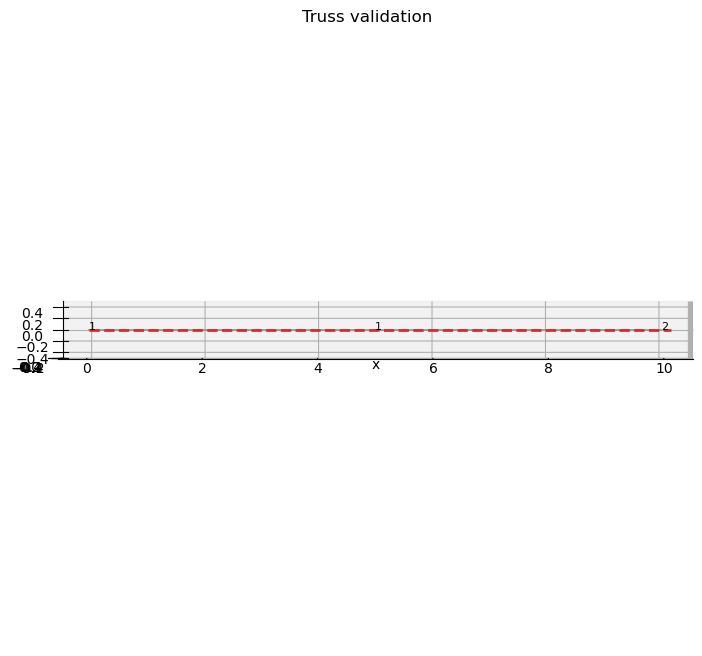

In [36]:
import importlib

try:
    import helpers.plotting_simple as ps
    importlib.reload(ps)

    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
    from helpers.plotting_simple import plot_structure_simple
except ImportError:
    import plotting_simple as ps
    importlib.reload(ps)

    from preprocess import preprocess_model
    from solver import solve_complete_model
    from plotting_simple import plot_structure_simple

model_path = "inputs/validation/validation_3d_truss.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

_ = plot_structure_simple(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=500,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_node_labels=True,
    show_element_labels=True,
    title="Truss validation",
    view="side",
)

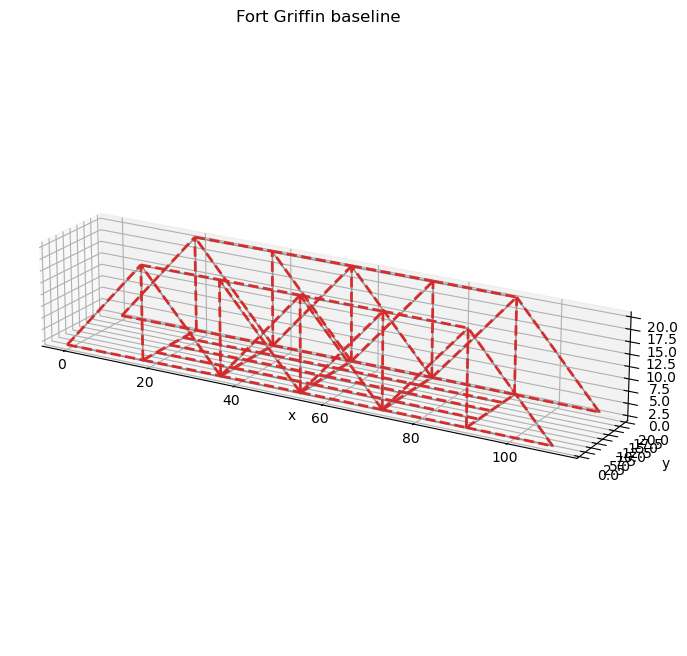

In [37]:
model_path = "inputs/final_bridge/fort_griffin_main_span.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

_ = plot_structure_simple(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=3000,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_node_labels=False,
    show_element_labels=False,
    title="Fort Griffin baseline",
    view="iso",
    save_path="outputs/final_bridge/fort_griffin_baseline_simple_plot.png",
)

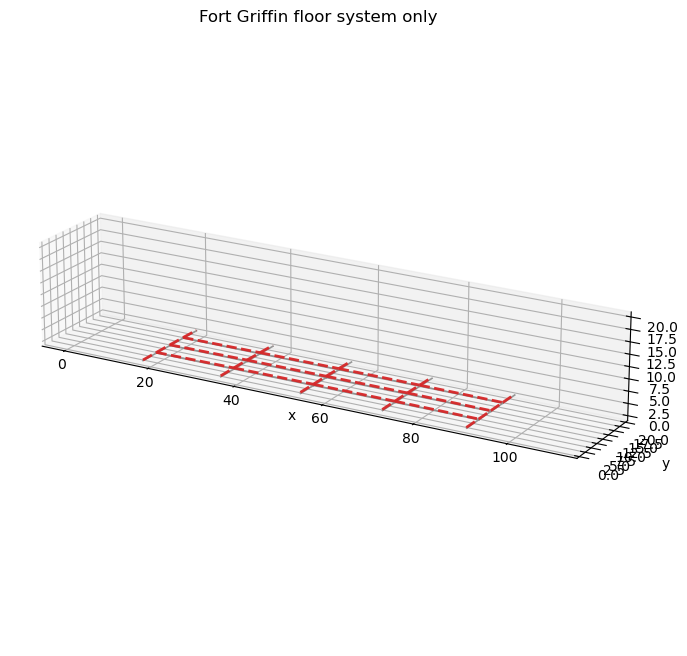

In [38]:
model_path = "inputs/final_bridge/fort_griffin_main_span.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

_ = plot_structure_simple(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=3000,
    selector="floor_system",
    show_undeformed=True,
    show_deformed=True,
    show_node_labels=False,
    show_element_labels=False,
    title="Fort Griffin floor system only",
    view="iso",
    save_path="outputs/final_bridge/fort_griffin_floor_system_simple_plot.png",
)

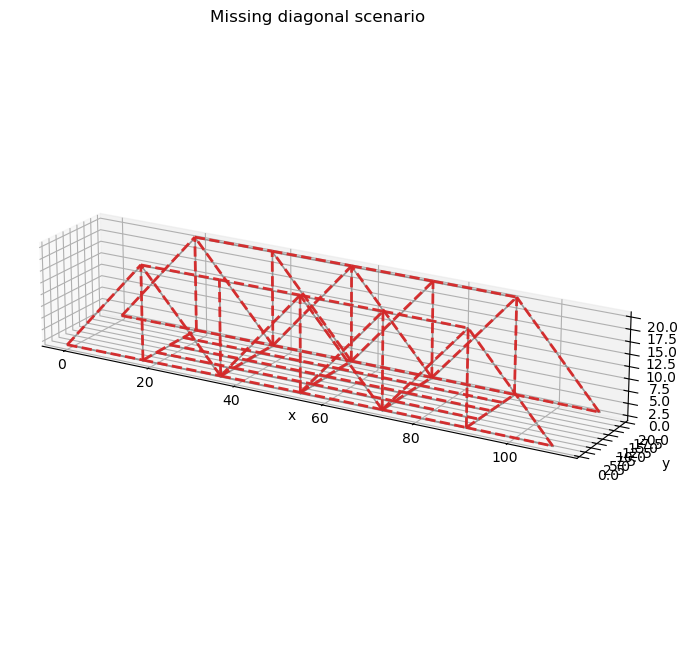

In [39]:
import importlib

try:
    import helpers.plotting_simple as ps
    importlib.reload(ps)

    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
    from helpers.plotting_simple import plot_structure_simple
except ImportError:
    import plotting_simple as ps
    importlib.reload(ps)

    from preprocess import preprocess_model
    from solver import solve_complete_model
    from plotting_simple import plot_structure_simple

model_path = "inputs/final_bridge/scenario_missing_diagonal.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

_ = plot_structure_simple(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=3000,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_node_labels=False,
    show_element_labels=False,
    title="Missing diagonal scenario",
    view="iso",
    save_path="outputs/final_bridge/scenario_missing_diagonal_simple_plot.png",
)

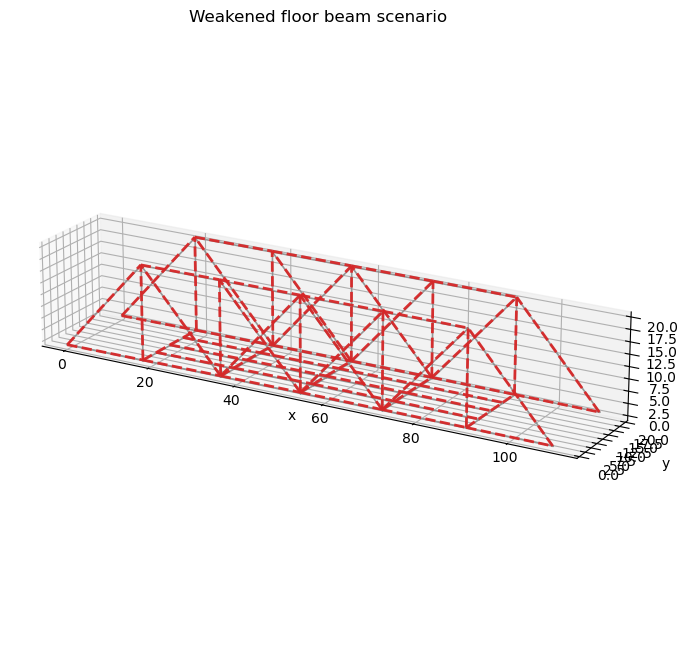

In [40]:
model_path = "inputs/final_bridge/scenario_weakened_floor_beam.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

_ = plot_structure_simple(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=3000,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_node_labels=False,
    show_element_labels=False,
    title="Weakened floor beam scenario",
    view="iso",
    save_path="outputs/final_bridge/scenario_weakened_floor_beam_simple_plot.png",
)

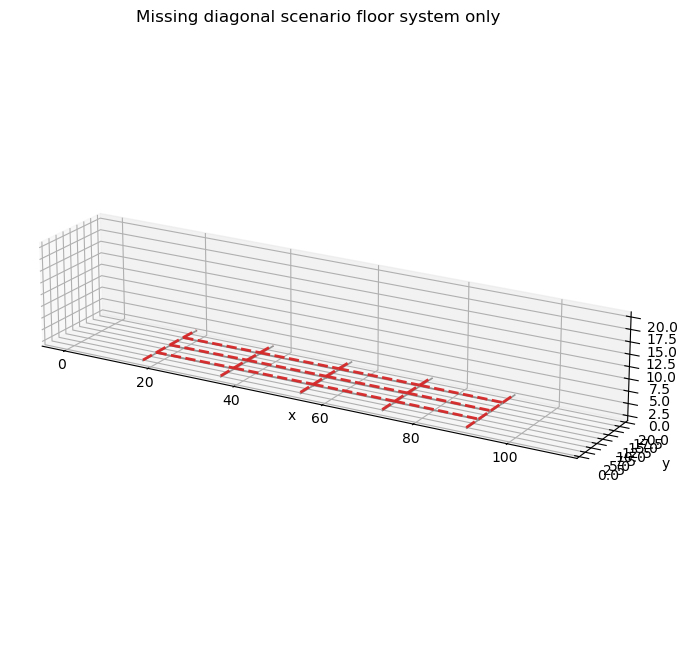

In [41]:
model_path = "inputs/final_bridge/scenario_missing_diagonal.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

_ = plot_structure_simple(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=3000,
    selector="floor_system",
    show_undeformed=True,
    show_deformed=True,
    show_node_labels=False,
    show_element_labels=False,
    title="Missing diagonal scenario floor system only",
    view="iso",
    save_path="outputs/final_bridge/scenario_missing_diagonal_floor_system_simple_plot.png",
)

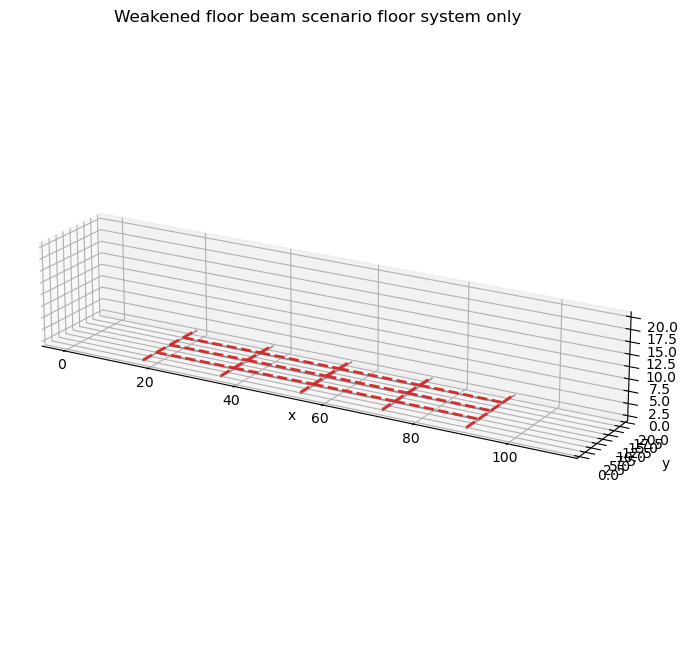

In [42]:
model_path = "inputs/final_bridge/scenario_weakened_floor_beam.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

_ = plot_structure_simple(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=3000,
    selector="floor_system",
    show_undeformed=True,
    show_deformed=True,
    show_node_labels=False,
    show_element_labels=False,
    title="Weakened floor beam scenario floor system only",
    view="iso",
    save_path="outputs/final_bridge/scenario_weakened_floor_beam_floor_system_simple_plot.png",
)

In [43]:
import importlib

try:
    import helpers.plotting_plotly as pp3d
    importlib.reload(pp3d)

    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
    from helpers.plotting_plotly import plot_structure_plotly
except ImportError:
    import plotting_plotly as pp3d
    importlib.reload(pp3d)

    from preprocess import preprocess_model
    from solver import solve_complete_model
    from plotting_plotly import plot_structure_plotly

model_path = "inputs/final_bridge/fort_griffin_main_span.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=3000,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=True,
    title="Fort Griffin baseline interactive",
    save_html="outputs/final_bridge/plotly_plots/fort_griffin_baseline_interactive.html",
    save_png="outputs/final_bridge/plotly_plots/fort_griffin_baseline_interactive.png",
)
fig.show()

In [44]:
import plotly.express as px

fig = px.line(x=[1, 2, 3], y=[2, 1, 4])
fig.write_image("figure.png")

In [45]:
model_path = "inputs/final_bridge/fort_griffin_main_span.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=3000,
    selector="floor_system",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=True,
    title="Fort Griffin floor system interactive",
    save_html="outputs/final_bridge/fort_griffin_floor_system_interactive.html",
)
fig.show()

In [51]:
import importlib

try:
    import helpers.plotting_plotly as pp3d
    importlib.reload(pp3d)

    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
    from helpers.plotting_plotly import plot_structure_plotly
except ImportError:
    import plotting_plotly as pp3d
    importlib.reload(pp3d)

    from preprocess import preprocess_model
    from solver import solve_complete_model
    from plotting_plotly import plot_structure_plotly

model_path = "inputs/final_bridge/scenario_missing_diagonal.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=3000,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=True,
    title="Missing diagonal scenario interactive",
    save_html="outputs/final_bridge/plotly_plots/scenario_missing_diagonal_interactive.html",
    save_png="outputs/final_bridge/plotly_plots/scenario_missing_diagonal_interactive.png",
)
fig.show()

In [52]:
model_path = "inputs/final_bridge/scenario_weakened_floor_beam.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=3000,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=True,
    title="Weakened floor beam scenario interactive",
    save_html="outputs/final_bridge/plotly_plots/scenario_weakened_floor_beam_interactive.html",
    save_png="outputs/final_bridge/plotly_plots/scenario_weakened_floor_beam_interactive.png",
)
fig.show()

In [48]:
model_path = "inputs/final_bridge/scenario_weakened_floor_beam.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=3000,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=True,
    title="Weakened floor beam scenario interactive",
    save_html="outputs/final_bridge/scenario_weakened_floor_beam_interactive.html",
)
fig.show()

In [49]:
model_path = "inputs/final_bridge/scenario_missing_diagonal.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=3000,
    selector="floor_system",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=True,
    title="Missing diagonal scenario floor system interactive",
    save_html="outputs/final_bridge/scenario_missing_diagonal_floor_system_interactive.html",
)
fig.show()

In [50]:
model_path = "inputs/final_bridge/scenario_weakened_floor_beam.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=3000,
    selector="floor_system",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=True,
    title="Weakened floor beam scenario floor system interactive",
    save_html="outputs/final_bridge/scenario_weakened_floor_beam_floor_system_interactive.html",
)
fig.show()

In [54]:
import importlib

try:
    import helpers.plotting_plotly as pp3d
    importlib.reload(pp3d)

    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
    from helpers.plotting_plotly import plot_structure_plotly
except ImportError:
    import plotting_plotly as pp3d
    importlib.reload(pp3d)

    from preprocess import preprocess_model
    from solver import solve_complete_model
    from plotting_plotly import plot_structure_plotly

model_path = "inputs/validation/validation_3d_frame.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    R=package["results"]["R"],
    scale=100,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=True,
    show_node_labels=True,
    show_element_hover=True,
    show_nodal_loads=True,
    show_reactions=True,
    load_scale=1.5,
    reaction_scale=1.5,
    title="Frame validation with nodal loads and reactions",
    save_html="outputs/validation/frame_validation_loads_reactions_interactive.html",
    save_png="outputs/validation/frame_validation_loads_reactions_interactive.png",
)
fig.show()

In [55]:
model_path = "inputs/final_bridge/fort_griffin_main_span.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    R=package["results"]["R"],
    scale=3000,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=True,
    show_nodal_loads=False,
    show_reactions=True,
    reaction_scale=20,
    title="Fort Griffin baseline with reactions",
    save_html="outputs/final_bridge/plotly_plots/fort_griffin_baseline_reactions_interactive.html",
    save_png="outputs/final_bridge/plotly_plots/fort_griffin_baseline_reactions_interactive.png",
)
fig.show()

In [56]:
import importlib

try:
    import helpers.plotting_plotly as pp3d
    importlib.reload(pp3d)

    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
    from helpers.plotting_plotly import plot_structure_plotly
except ImportError:
    import plotting_plotly as pp3d
    importlib.reload(pp3d)

    from preprocess import preprocess_model
    from solver import solve_complete_model
    from plotting_plotly import plot_structure_plotly

model_path = "inputs/validation/verification_member_loads_z.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    R=package["results"]["R"],
    scale=50,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=True,
    show_node_labels=True,
    show_element_hover=True,
    show_nodal_loads=False,
    show_member_loads=True,
    show_reactions=True,
    reaction_scale=1.2,
    member_load_scale=8.0,
    title="Frame verification with member load and reactions",
    save_html="outputs/validation/frame_verification_member_loads_interactive.html",
    save_png="outputs/validation/frame_verification_member_loads_interactive.png",
)
fig.show()

In [59]:
model_path = "inputs/final_bridge/fort_griffin_main_span.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    R=package["results"]["R"],
    scale=3000,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=True,
    show_nodal_loads=False,
    show_member_loads=True,
    show_reactions=True,
    reaction_scale=12,
    member_load_scale=60,
    title="Fort Griffin baseline with member loads and reactions",
    save_html="outputs/final_bridge/plotly_plots/fort_griffin_baseline_loads_reactions_interactive.html",
    save_png="outputs/final_bridge/plotly_plots/fort_griffin_baseline_loads_reactions_interactive.png",
)
fig.show()

In [60]:
model_path = "inputs/final_bridge/fort_griffin_main_span.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    R=package["results"]["R"],
    scale=3000,
    selector="floor_system",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=True,
    show_nodal_loads=False,
    show_member_loads=True,
    show_reactions=False,
    member_load_scale=60,
    title="Fort Griffin floor system with member loads",
    save_html="outputs/final_bridge/plotly_plots/fort_griffin_floor_system_loads_interactive.html",
    save_png="outputs/final_bridge/plotly_plots/fort_griffin_floor_system_loads_interactive.png",
)
fig.show()

In [61]:
def apply_bridge_camera(fig, mode="iso"):
    if mode == "iso":
        fig.update_layout(
            scene_camera=dict(
                eye=dict(x=1.7, y=1.4, z=0.8)
            )
        )
    elif mode == "wide_iso":
        fig.update_layout(
            scene_camera=dict(
                eye=dict(x=2.2, y=1.6, z=0.8)
            )
        )
    elif mode == "floor":
        fig.update_layout(
            scene_camera=dict(
                eye=dict(x=1.9, y=1.3, z=0.35)
            )
        )
    else:
        raise ValueError(f"Unknown camera mode {mode}")

In [62]:
import importlib

try:
    import helpers.plotting_plotly as pp3d
    importlib.reload(pp3d)

    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
    from helpers.plotting_plotly import plot_structure_plotly
except ImportError:
    import plotting_plotly as pp3d
    importlib.reload(pp3d)

    from preprocess import preprocess_model
    from solver import solve_complete_model
    from plotting_plotly import plot_structure_plotly

model_path = "inputs/final_bridge/fort_griffin_main_span.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=3000,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=True,
    show_nodal_loads=False,
    show_member_loads=False,
    show_reactions=False,
    title="Fort Griffin baseline",
    save_html="outputs/final_bridge/plotly_plots/final_01_baseline_full_bridge.html",
    save_png="outputs/final_bridge/plotly_plots/final_01_baseline_full_bridge.png",
)
apply_bridge_camera(fig, "wide_iso")
fig.show()

In [63]:
model_path = "inputs/final_bridge/fort_griffin_main_span.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    R=package["results"]["R"],
    scale=3000,
    selector="floor_system",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=True,
    show_nodal_loads=False,
    show_member_loads=True,
    show_reactions=False,
    member_load_scale=60,
    title="Fort Griffin baseline floor system with member loads",
    save_html="outputs/final_bridge/plotly_plots/final_02_baseline_floor_system_loads.html",
    save_png="outputs/final_bridge/plotly_plots/final_02_baseline_floor_system_loads.png",
)
apply_bridge_camera(fig, "floor")
fig.show()

In [64]:
model_path = "inputs/final_bridge/scenario_missing_diagonal.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=3000,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=True,
    show_nodal_loads=False,
    show_member_loads=False,
    show_reactions=False,
    title="Missing diagonal scenario",
    save_html="outputs/final_bridge/plotly_plots/final_03_missing_diagonal_full_bridge.html",
    save_png="outputs/final_bridge/plotly_plots/final_03_missing_diagonal_full_bridge.png",
)
apply_bridge_camera(fig, "wide_iso")
fig.show()

In [65]:
model_path = "inputs/final_bridge/scenario_weakened_floor_beam.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=3000,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=True,
    show_nodal_loads=False,
    show_member_loads=False,
    show_reactions=False,
    title="Weakened floor beam scenario",
    save_html="outputs/final_bridge/plotly_plots/final_04_weakened_floor_beam_full_bridge.html",
    save_png="outputs/final_bridge/plotly_plots/final_04_weakened_floor_beam_full_bridge.png",
)
apply_bridge_camera(fig, "wide_iso")
fig.show()

In [66]:
model_path = "inputs/final_bridge/scenario_weakened_floor_beam.json"
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    R=package["results"]["R"],
    scale=3000,
    selector="floor_system",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=True,
    show_nodal_loads=False,
    show_member_loads=True,
    show_reactions=False,
    member_load_scale=60,
    title="Weakened floor beam scenario floor system with member loads",
    save_html="outputs/final_bridge/plotly_plots/final_05_weakened_floor_beam_floor_system.html",
    save_png="outputs/final_bridge/plotly_plots/final_05_weakened_floor_beam_floor_system.png",
)
apply_bridge_camera(fig, "floor")
fig.show()